In [291]:
# Descargar el repositorio solamente si aún no existe
from pathlib import Path

RUTA_REPOSITORIO = Path("/content/programacionCientifica")

if not RUTA_REPOSITORIO.exists():
    !git clone --depth 1 https://github.com/manubastidas/programacionCientifica.git
else:
    print("El repositorio ya existe en esta sesión.")

El repositorio ya existe en esta sesión.


In [221]:
# Entrar a la carpeta de la Evaluación 2
%cd /content/programacionCientifica/Evaluacion2

# Mostrar los archivos existentes
!ls -lh

/content/programacionCientifica/Evaluacion2
total 156K
-rw-r--r--  1 root root  52K Jul  3 17:09 datos_1234.npz
-rw-r--r--  1 root root  64K Jul  3 17:27 datos_698.npz
-rw-r--r--  1 root root 4.8K Jul  3 17:09 enunciado_1234.md
-rw-r--r--  1 root root 4.8K Jul  3 17:27 enunciado_698.md
-rw-r--r--  1 root root 2.5K Jul  3 17:09 generar_datos.py
-rw-r--r--  1 root root 6.5K Jul  3 17:09 generar_enunciado.py
-rw-r--r--  1 root root 4.3K Jul  3 17:09 Instrucciones.md
drwxr-xr-x 11 root root 4.0K Jul  3 17:24 programacionCientifica


In [222]:
# Escribe aquí solamente los últimos cuatro dígitos de tu documento
ID = "0698"

# Generar el enunciado y los datos personalizados
!python generar_enunciado.py {ID}
!python generar_datos.py {ID}

Enunciado generado para cédula 698: enunciado_698.md
Los parámetros: K=15, iteraciones=4000, η=0.05, n=10/régimen, régimen foco=2, compresión 85%
Datos generados para cédula 698: X=(30, 256), y=(30,), t=(256,)
Guardado en datos_698.npz


In [223]:
# Cargar los datos personalizados desde la sesión actual
from pathlib import Path
import numpy as np

ruta_datos = Path("datos_698.npz")

if not ruta_datos.exists():
    raise FileNotFoundError(
        "No se encontró datos_698.npz. "
        "Ejecuta primero la celda que genera los datos personalizados."
    )

datos = np.load(ruta_datos)

X = datos["X"]
y = datos["y"]
t = datos["t"]

print("Datos cargados correctamente.")
print("Ruta utilizada:", ruta_datos.resolve())
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Forma de t:", t.shape)

Datos cargados correctamente.
Ruta utilizada: /content/programacionCientifica/Evaluacion2/datos_698.npz
Forma de X: (30, 256)
Forma de y: (30,)
Forma de t: (256,)


In [224]:
# Respaldo opcional en Google Drive
# No es necesario para ejecutar el resto del notebook.

HACER_RESPALDO_EN_DRIVE = False

if HACER_RESPALDO_EN_DRIVE:
    from google.colab import drive
    from pathlib import Path
    import shutil

    drive.mount("/content/drive")

    carpeta_origen = Path(
        "/content/programacionCientifica/Evaluacion2"
    )

    carpeta_drive = Path(
        "/content/drive/MyDrive/"
        "ProgramacionCientifica/Evaluacion2_Corredor"
    )

    carpeta_drive.mkdir(
        parents=True,
        exist_ok=True
    )

    archivos = [
        "enunciado_698.md",
        "datos_698.npz"
    ]

    for nombre in archivos:
        origen = carpeta_origen / nombre
        destino = carpeta_drive / nombre

        if origen.exists():
            shutil.copy2(origen, destino)
            print(f"Copiado correctamente: {destino}")
        else:
            print(f"No se encontró: {origen}")

    print("\nArchivos guardados en Google Drive:")

    for archivo in carpeta_drive.iterdir():
        print("-", archivo.name)

else:
    print(
        "Respaldo en Google Drive desactivado. "
        "El notebook continuará usando los archivos locales."
    )

Respaldo en Google Drive desactivado. El notebook continuará usando los archivos locales.


# Evaluación 2 — Programación Científica

**Universidad Nacional de Colombia — Sede Medellín**

**Estudiante:** Julián Corredor  
**Asignatura:** Programación Científica  
**Evaluación:** Actividad evaluativa #2  
**Entorno de desarrollo:** Google Colab  
**Archivo de datos:** `datos_698.npz`

---

## Parámetros personalizados

Los parámetros de esta evaluación fueron generados a partir de los últimos cuatro dígitos del documento de identidad.

| Parámetro | Valor |
|---|---:|
| Número de frecuencias \(K\) | 15 |
| Iteraciones de entrenamiento | 4000 |
| Tasa de aprendizaje \(\eta\) | 0.05 |
| Señales por régimen | 10 |
| Régimen de análisis detallado | 2 |
| Umbral de energía para compresión | 85 % |

In [6]:
# Librerías para calculo y visualización
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Parámetros personalizados de la evaluación
K = 15
N_ITER = 4000
ETA = 0.05
REGIMEN_FOCO = 2
UMBRAL_ENERGIA = 0.85

print("Parámetros cargados correctamente.")

Parámetros cargados correctamente.


In [7]:
# Información general del conjunto de datos
print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)
print("Dimensión de t:", t.shape)

print("\nTipo de datos de X:", X.dtype)
print("Tiempo inicial:", t[0])
print("Tiempo final:", t[-1])

print("\nCantidad de señales por régimen:")
for regimen in np.unique(y):
    cantidad = np.sum(y == regimen)
    print(f"Régimen {regimen}: {cantidad} señales")

Dimensión de X: (30, 256)
Dimensión de y: (30,)
Dimensión de t: (256,)

Tipo de datos de X: float64
Tiempo inicial: 0.0
Tiempo final: 0.99609375

Cantidad de señales por régimen:
Régimen 0: 10 señales
Régimen 1: 10 señales
Régimen 2: 10 señales


## Energía media del conjunto de datos

Para una señal discreta \(x_j\), una medida asociada a su energía media es el promedio de sus valores al cuadrado:

$$
E=\frac{1}{N}\sum_{j=1}^{N}x_j^2.
$$

Como el conjunto contiene varias señales, se calcula el promedio sobre todos los elementos de la matriz \(X\):

$$
E_{\mathrm{media}}
=
\frac{1}{N_{\mathrm{señales}}N_{\mathrm{muestras}}}
\sum_{i=1}^{N_{\mathrm{señales}}}
\sum_{j=1}^{N_{\mathrm{muestras}}}
X_{ij}^{2}.
$$

En NumPy, esta operación se implementa mediante:

```python
(X**2).mean()

In [8]:
# Energía media de todo el dataset
energia_media = np.mean(X**2)

print(f"Energía media del dataset: {energia_media:.3f}")

Energía media del dataset: 0.715


In [9]:
# Verificaciones básicas de integridad
assert X.shape == (30, 256), "La dimensión de X no es la esperada."
assert y.shape == (30,), "La dimensión de y no es la esperada."
assert t.shape == (256,), "La dimensión de t no es la esperada."

assert np.all(np.isfinite(X)), "X contiene valores NaN o infinitos."
assert np.all(np.isfinite(t)), "t contiene valores NaN o infinitos."
assert set(np.unique(y)) == {0, 1, 2}, "Las etiquetas no coinciden con los tres regímenes."

print("Todas las verificaciones fueron superadas correctamente.")

Todas las verificaciones fueron superadas correctamente.


## Construcción de la capa Fourier

Una señal periódica puede representarse mediante una combinación de funciones seno y coseno:

$$
x(t)\approx
\sum_{k=1}^{K}
\left[
a_k\cos(2\pi kt)
+
b_k\sin(2\pi kt)
\right].
$$

En esta evaluación se construye una matriz Fourier \(W_1\) cuyas filas contienen estas funciones base evaluadas en los 256 instantes de muestreo.

Para \(K=15\), la matriz tiene dimensión:

$$
W_1\in\mathbb{R}^{2K\times256}
=
\mathbb{R}^{30\times256}.
$$

Las primeras \(K\) filas corresponden a cosenos y las siguientes \(K\) filas corresponden a senos.

In [10]:
def construir_capa_fourier(t, K):
    """
    Construye una matriz Fourier real con filas de cosenos y senos.

    Parámetros
    ----------
    t : array de forma (N,)
        Instantes de muestreo.
    K : int
        Número de frecuencias positivas.

    Retorna
    -------
    W_fourier : array de forma (2*K, N)
        Primeras K filas: cosenos.
        Últimas K filas: senos.
    """
    t = np.asarray(t)

    frecuencias = np.arange(1, K + 1)

    # Producto exterior: cada fila corresponde a una frecuencia k
    angulos = 2 * np.pi * np.outer(frecuencias, t)

    filas_coseno = np.cos(angulos)
    filas_seno = np.sin(angulos)

    W_fourier = np.vstack([filas_coseno, filas_seno])

    return W_fourier


W_fourier = construir_capa_fourier(t, K)

print("Dimensión de W_fourier:", W_fourier.shape)

Dimensión de W_fourier: (30, 256)


In [11]:
assert W_fourier.shape == (2 * K, len(t))
assert np.all(np.isfinite(W_fourier))

print("La capa Fourier fue construida correctamente.")

La capa Fourier fue construida correctamente.


In [12]:
# Configuración general para visualización científica
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

mpl.rcParams.update({
    # Tipografía científica
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 12,

    # Tamaño de textos
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "axes.titleweight": "semibold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,

    # Marcas de los ejes
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,

    # Eliminar bordes que no aportan información
    "axes.spines.top": False,
    "axes.spines.right": False,

    # Resolución
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

print("Estilo científico configurado correctamente.")

Estilo científico configurado correctamente.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


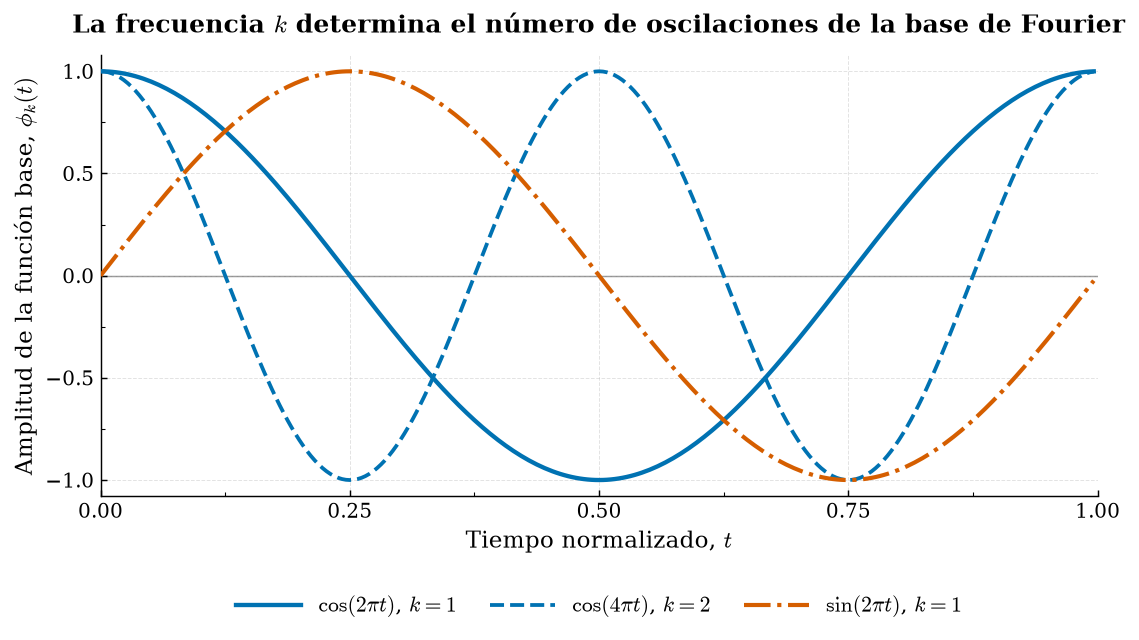

In [13]:

COLOR_COSENO = "#0072B2"   # azul: familia de cosenos
COLOR_SENO = "#D55E00"     # naranja rojizo: familia de senos
COLOR_NEUTRO = "#5A5A5A"   # elementos auxiliares

# Crear la figura
fig, ax = plt.subplots(
    figsize=(8.6, 4.8),
    layout="constrained"
)

# Funciones base seleccionadas
cos_k1 = W_fourier[0]       # cos(2πt), k = 1
cos_k2 = W_fourier[1]       # cos(4πt), k = 2
sin_k1 = W_fourier[K]       # sin(2πt), k = 1

# Dibujar las curvas.
# El color identifica la familia y el estilo de línea ayuda a diferenciarlas.
ax.plot(
    t,
    cos_k1,
    color=COLOR_COSENO,
    linewidth=2.4,
    linestyle="-",
    label=r"$\cos(2\pi t)$, $k=1$",
    zorder=3
)

ax.plot(
    t,
    cos_k2,
    color=COLOR_COSENO,
    linewidth=2.1,
    linestyle="--",
    label=r"$\cos(4\pi t)$, $k=2$",
    zorder=3
)

ax.plot(
    t,
    sin_k1,
    color=COLOR_SENO,
    linewidth=2.3,
    linestyle="-.",
    label=r"$\sin(2\pi t)$, $k=1$",
    zorder=3
)

# Línea de referencia en amplitud cero
ax.axhline(
    0,
    color=COLOR_NEUTRO,
    linewidth=0.8,
    alpha=0.65,
    zorder=1
)

# Límites completos: no se recorta ninguna amplitud
ax.set_xlim(0, 1)
ax.set_ylim(-1.08, 1.08)

# Marcas principales y secundarias
ax.xaxis.set_major_locator(MultipleLocator(0.25))
ax.xaxis.set_minor_locator(MultipleLocator(0.125))
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_minor_locator(MultipleLocator(0.25))

# Cuadrícula tenue: sirve de guía, pero no domina la información
ax.grid(
    True,
    which="major",
    color="#B0B0B0",
    linestyle="--",
    linewidth=0.55,
    alpha=0.35,
    zorder=0
)

# Etiquetas físicas y matemáticas
ax.set_xlabel(r"Tiempo normalizado, $t$")
ax.set_ylabel(r"Amplitud de la función base, $\phi_k(t)$")

# El título comunica la idea principal, no solamente el contenido
ax.set_title(
    r"La frecuencia $k$ determina el número de oscilaciones "
    r"de la base de Fourier",
    pad=12
)

# Leyenda compacta, sin caja opaca
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    frameon=False,
    handlelength=3.0,
    columnspacing=1.5
)

plt.show()

**Figura 1. Funciones base utilizadas para inicializar la primera capa de la red neuronal.**

Se muestran funciones seno y coseno para las frecuencias $k=1$ y $k=2$. Al aumentar el valor de $k$, también aumenta el número de oscilaciones dentro del mismo intervalo temporal.

Las primeras $K$ filas de la matriz $W_1$ corresponden a funciones coseno, mientras que las siguientes $K$ filas corresponden a funciones seno.

En esta evaluación, $K=15$. Por tanto, la matriz Fourier tiene dimensiones:

$$
W_1 \in \mathbb{R}^{30 \times 256}.
$$

## Verificación de la capa Fourier con `np.fft`

La transformada discreta de Fourier de una señal $x_n$ de longitud $N$ se define como:

$$
X_k=
\sum_{n=0}^{N-1}
x_n
e^{-2\pi i kn/N}.
$$

Utilizando la identidad de Euler,

$$
e^{-i\theta}
=
\cos(\theta)-i\sin(\theta),
$$

se obtiene:

$$
X_k=
\sum_{n=0}^{N-1}
x_n\cos\left(\frac{2\pi kn}{N}\right)
-
i
\sum_{n=0}^{N-1}
x_n\sin\left(\frac{2\pi kn}{N}\right).
$$

Por tanto, la parte real de la transformada corresponde a la proyección sobre las funciones coseno:

$$
\operatorname{Re}(X_k)
=
\sum_{n=0}^{N-1}
x_n\cos\left(\frac{2\pi kn}{N}\right),
$$

mientras que la proyección sobre las funciones seno corresponde al negativo de la parte imaginaria:

$$
-\operatorname{Im}(X_k)
=
\sum_{n=0}^{N-1}
x_n\sin\left(\frac{2\pi kn}{N}\right).
$$

La matriz $W_1$ construida anteriormente debe producir exactamente estas dos cantidades, salvo pequeñas diferencias debidas a la precisión numérica.

In [14]:
# Seleccionar la primera señal perteneciente al régimen de análisis detallado
indices_regimen_foco = np.flatnonzero(y == REGIMEN_FOCO)

if len(indices_regimen_foco) == 0:
    raise ValueError(
        f"No se encontraron señales del régimen {REGIMEN_FOCO}."
    )

indice_ejemplo = indices_regimen_foco[0]
senal_ejemplo = X[indice_ejemplo]

print(f"Índice seleccionado: {indice_ejemplo}")
print(f"Régimen de la señal: {y[indice_ejemplo]}")
print(f"Número de muestras: {senal_ejemplo.size}")

Índice seleccionado: 7
Régimen de la señal: 2
Número de muestras: 256


In [15]:
# Aplicar la matriz Fourier a la señal seleccionada
coeficientes_capa = W_fourier @ senal_ejemplo

# La matriz está organizada así:
# - primeras K filas: funciones coseno
# - últimas K filas: funciones seno
coef_cos_capa = coeficientes_capa[:K]
coef_sin_capa = coeficientes_capa[K:]

# Verificaciones de dimensiones
assert coeficientes_capa.shape == (2 * K,)
assert coef_cos_capa.shape == (K,)
assert coef_sin_capa.shape == (K,)

print(f"Señal analizada: X[{indice_ejemplo}]")
print(f"Régimen: {y[indice_ejemplo]}")
print(f"Forma de W_fourier @ x: {coeficientes_capa.shape}")
print(f"Coeficientes coseno: {coef_cos_capa.shape}")
print(f"Coeficientes seno:   {coef_sin_capa.shape}")

Señal analizada: X[7]
Régimen: 2
Forma de W_fourier @ x: (30,)
Coeficientes coseno: (15,)
Coeficientes seno:   (15,)


In [16]:
# Transformada discreta de Fourier para una señal real
fft_ejemplo = np.fft.rfft(senal_ejemplo)

# Índices de frecuencia presentes en la capa Fourier
frecuencias = np.arange(1, K + 1)

# Se excluye k = 0 porque W_fourier fue construida para k = 1, ..., K
fft_frecuencias = fft_ejemplo[1:K + 1]

# Proyección sobre cosenos: parte real
coef_cos_fft = fft_frecuencias.real

# Proyección sobre senos: negativo de la parte imaginaria
coef_sin_fft = -fft_frecuencias.imag

# Verificaciones
assert coef_cos_fft.shape == (K,)
assert coef_sin_fft.shape == (K,)

print(f"Forma completa de np.fft.rfft: {fft_ejemplo.shape}")
print(f"Frecuencias comparadas: k = 1, ..., {K}")

Forma completa de np.fft.rfft: (129,)
Frecuencias comparadas: k = 1, ..., 15


In [17]:
# Diferencias entre los coeficientes obtenidos por ambos métodos
diferencia_cos = coef_cos_capa - coef_cos_fft
diferencia_sin = coef_sin_capa - coef_sin_fft

# Errores máximos absolutos
error_max_cos = np.max(np.abs(diferencia_cos))
error_max_sin = np.max(np.abs(diferencia_sin))
error_max_total = max(error_max_cos, error_max_sin)

# Unir todos los coeficientes para calcular un error relativo global
coef_capa_completos = np.concatenate([
    coef_cos_capa,
    coef_sin_capa
])

coef_fft_completos = np.concatenate([
    coef_cos_fft,
    coef_sin_fft
])

norma_fft = np.linalg.norm(coef_fft_completos)

if norma_fft == 0:
    raise ZeroDivisionError(
        "No es posible calcular el error relativo porque "
        "la norma de los coeficientes FFT es cero."
    )

error_relativo_fft = (
    np.linalg.norm(coef_capa_completos - coef_fft_completos)
    / norma_fft
)

print("Comparación numérica")
print("-" * 42)
print(f"Error máximo en cosenos : {error_max_cos:.3e}")
print(f"Error máximo en senos   : {error_max_sin:.3e}")
print(f"Error máximo total      : {error_max_total:.3e}")
print(f"Error relativo global   : {error_relativo_fft:.3e}")

Comparación numérica
------------------------------------------
Error máximo en cosenos : 4.530e-14
Error máximo en senos   : 9.592e-14
Error máximo total      : 9.592e-14
Error relativo global   : 2.699e-15


In [18]:
# Tolerancia para diferencias debidas a precisión de punto flotante
TOLERANCIA_FFT = 1e-10

coinciden_cosenos = np.allclose(
    coef_cos_capa,
    coef_cos_fft,
    atol=TOLERANCIA_FFT,
    rtol=TOLERANCIA_FFT
)

coinciden_senos = np.allclose(
    coef_sin_capa,
    coef_sin_fft,
    atol=TOLERANCIA_FFT,
    rtol=TOLERANCIA_FFT
)

assert coinciden_cosenos, (
    "La proyección sobre cosenos no coincide con "
    "la parte real de np.fft."
)

assert coinciden_senos, (
    "La proyección sobre senos no coincide con "
    "el negativo de la parte imaginaria de np.fft."
)

print(
    "Verificación superada: la capa Fourier reproduce "
    "los coeficientes calculados mediante np.fft."
)

Verificación superada: la capa Fourier reproduce los coeficientes calculados mediante np.fft.


findfont: Failed to find font weight semibold, now using 700.


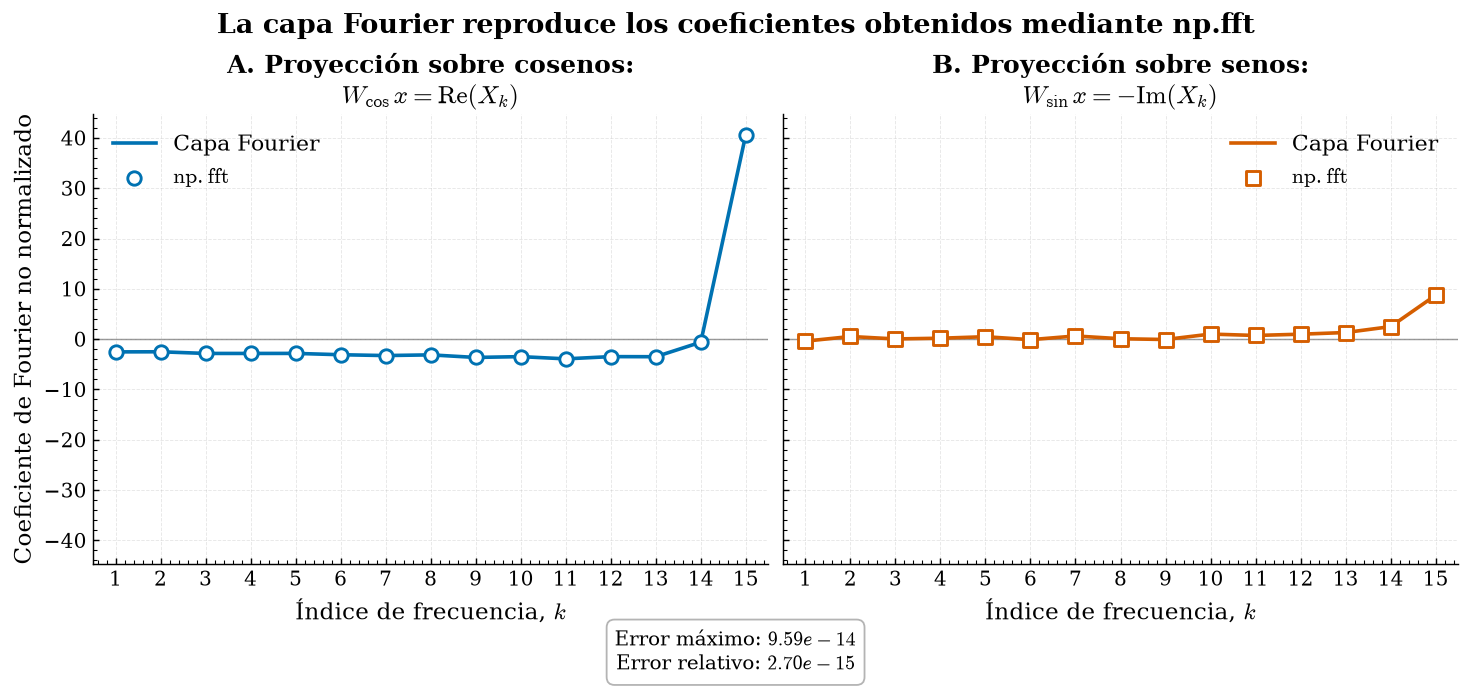

In [19]:
# Límite vertical común para facilitar la comparación entre paneles
maximo_coeficiente = np.max(
    np.abs(
        np.concatenate([
            coef_cos_capa,
            coef_sin_capa,
            coef_cos_fft,
            coef_sin_fft
        ])
    )
)

limite_vertical = 1.10 * maximo_coeficiente

# Crear la figura
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(11.2, 4.8),
    sharex=True,
    sharey=True,
    layout="constrained"
)

ax_cos, ax_sin = axes

# ---------------------------------------------------------
# Panel A: coeficientes asociados a cosenos
# ---------------------------------------------------------
ax_cos.plot(
    frecuencias,
    coef_cos_capa,
    color=COLOR_COSENO,
    linewidth=2.0,
    linestyle="-",
    label=r"Capa Fourier",
    zorder=2
)

ax_cos.scatter(
    frecuencias,
    coef_cos_fft,
    facecolors="white",
    edgecolors=COLOR_COSENO,
    linewidths=1.6,
    s=55,
    marker="o",
    label=r"$\mathrm{np.fft}$",
    zorder=3
)

ax_cos.axhline(
    0,
    color=COLOR_NEUTRO,
    linewidth=0.8,
    alpha=0.65,
    zorder=1
)

ax_cos.set_title(
    r"A. Proyección sobre cosenos:"
    "\n"
    r"$W_{\cos}x=\operatorname{Re}(X_k)$"
)

ax_cos.set_xlabel(r"Índice de frecuencia, $k$")
ax_cos.set_ylabel(r"Coeficiente de Fourier no normalizado")

# ---------------------------------------------------------
# Panel B: coeficientes asociados a senos
# ---------------------------------------------------------
ax_sin.plot(
    frecuencias,
    coef_sin_capa,
    color=COLOR_SENO,
    linewidth=2.0,
    linestyle="-",
    label=r"Capa Fourier",
    zorder=2
)

ax_sin.scatter(
    frecuencias,
    coef_sin_fft,
    facecolors="white",
    edgecolors=COLOR_SENO,
    linewidths=1.6,
    s=55,
    marker="s",
    label=r"$\mathrm{np.fft}$",
    zorder=3
)

ax_sin.axhline(
    0,
    color=COLOR_NEUTRO,
    linewidth=0.8,
    alpha=0.65,
    zorder=1
)

ax_sin.set_title(
    r"B. Proyección sobre senos:"
    "\n"
    r"$W_{\sin}x=-\operatorname{Im}(X_k)$"
)

ax_sin.set_xlabel(r"Índice de frecuencia, $k$")

# ---------------------------------------------------------
# Configuración común
# ---------------------------------------------------------
for ax in axes:
    ax.set_xlim(0.5, K + 0.5)
    ax.set_ylim(-limite_vertical, limite_vertical)
    ax.set_xticks(frecuencias)

    ax.grid(
        True,
        which="major",
        color="#B0B0B0",
        linestyle="--",
        linewidth=0.5,
        alpha=0.30,
        zorder=0
    )

    ax.legend(
        loc="best",
        frameon=False
    )

# Título general: comunica el resultado principal
fig.suptitle(
    "La capa Fourier reproduce los coeficientes obtenidos mediante np.fft",
    fontsize=15,
    fontweight="semibold"
)

# Resumen del error dentro de la figura
texto_error = (
    rf"Error máximo: ${error_max_total:.2e}$"
    "\n"
    rf"Error relativo: ${error_relativo_fft:.2e}$"
)

fig.text(
    0.5,
    0.005,
    texto_error,
    ha="center",
    va="top",
    fontsize=11,
    bbox={
        "facecolor": "white",
        "edgecolor": "#B0B0B0",
        "alpha": 0.95,
        "boxstyle": "round,pad=0.4"
    }
)

plt.show()

**Figura 2. Verificación de la capa Fourier mediante la transformada discreta de Fourier.**

Se comparan los coeficientes calculados por la multiplicación matricial $W_1x$ con los obtenidos mediante `np.fft.rfft` para una señal del régimen $2$.

En el panel A, la proyección sobre las funciones coseno coincide con la parte real de la transformada:

$$
W_{\cos}x=\operatorname{Re}(X_k).
$$

En el panel B, la proyección sobre las funciones seno coincide con el negativo de la parte imaginaria:

$$
W_{\sin}x=-\operatorname{Im}(X_k).
$$

La superposición entre las líneas y los marcadores, junto con un error numérico cercano a la precisión de punto flotante, confirma que la inicialización de la primera capa reproduce una transformada discreta de Fourier para las frecuencias $k=1,\ldots,15$.

### Resultado de la verificacion

La comparacion muestra que la multiplicacion matricial $W_1x$ reproduce los
coeficientes obtenidos con `np.fft.rfft` para las frecuencias
$k=1,\ldots,15$.

El error maximo obtenido fue:

$$
\varepsilon_{\max}=9.59\times10^{-14},
$$

mientras que el error relativo global fue:

$$
\varepsilon_{\mathrm{FFT}}=2.70\times10^{-15}.
$$

Estos valores son cercanos a la precision numerica de punto flotante. Por tanto,
las diferencias no corresponden a un error matematico, sino al redondeo propio
de las operaciones computacionales.

La senal seleccionada del regimen $2$ concentra parte importante de su contenido
en frecuencias altas, coherente con el regimen de dispersion fuerte asignado en
el enunciado personalizado.


# Parte IV — Red neuronal y reconstrucción

La red neuronal recibe una señal con 256 muestras, la transforma a una
representación interna de dimensión $2K=30$ y posteriormente intenta reconstruir
la señal original.

La arquitectura propuesta es:

$$
x\in\mathbb{R}^{256}
\longrightarrow
z\in\mathbb{R}^{30}
\longrightarrow
\hat{x}\in\mathbb{R}^{256}.
$$

La primera capa calcula:

$$
z=\tanh(W_1x),
$$

con:

$$
W_1\in\mathbb{R}^{30\times256}.
$$

La segunda capa reconstruye la señal:

$$
\hat{x}=W_2z,
$$

donde:

$$
W_2\in\mathbb{R}^{256\times30}.
$$

Se entrenarán dos redes con la misma arquitectura. La única diferencia será la
inicialización de $W_1$: una red comenzará con la matriz Fourier y la otra con
pesos aleatorios.

In [20]:
# Configuración de JAX antes de crear cualquier arreglo
from jax import config

# Activar precisión de 64 bits
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp

print("Versión de JAX:", jax.__version__)
print("Dispositivo disponible:", jax.devices()[0])
print("Precisión de 64 bits activada:", jax.config.x64_enabled)

Versión de JAX: 0.7.2
Dispositivo disponible: TFRT_CPU_0
Precisión de 64 bits activada: True


In [21]:
# Convertir los datos de NumPy a arreglos de JAX
# Esta conversión debe hacerse después de activar los 64 bits

X_jax = jnp.asarray(X, dtype=jnp.float64)
W_fourier_jax = jnp.asarray(W_fourier, dtype=jnp.float64)

print("Forma de X_jax:", X_jax.shape)
print("Forma de W_fourier_jax:", W_fourier_jax.shape)

print("Tipo de X_jax:", X_jax.dtype)
print("Tipo de W_fourier_jax:", W_fourier_jax.dtype)

# Verificaciones
assert X_jax.shape == (30, 256)
assert W_fourier_jax.shape == (2 * K, 256)

assert X_jax.dtype == jnp.float64
assert W_fourier_jax.dtype == jnp.float64

print("Datos convertidos correctamente a float64.")

Forma de X_jax: (30, 256)
Forma de W_fourier_jax: (30, 256)
Tipo de X_jax: float64
Tipo de W_fourier_jax: float64
Datos convertidos correctamente a float64.


## Inicializacion de los parametros de la red

Se compararan dos redes con la misma arquitectura y las mismas condiciones de
entrenamiento. La unica diferencia sera la inicializacion de la primera matriz
de pesos, $W_1$.

- **Red Fourier:** $W_1$ comienza con funciones seno y coseno.
- **Red aleatoria:** $W_1$ comienza con valores aleatorios.
- Ambas redes utilizan exactamente la misma matriz inicial $W_2$.

La matriz Fourier sin normalizar `W_fourier` se conserva para verificar la
coincidencia con `np.fft`. Para la parte de compresion se mantiene ademas una
base ortonormal:

$$
Q=\sqrt{\frac{2}{N}}\,W_{\mathrm{Fourier}},
$$

que cumple aproximadamente $QQ^{\mathsf T}=I$.

Para entrenar la red se usa una escala diferente en la primera capa Fourier:

$$
W_{1,\mathrm{Fourier}}^{\mathrm{red}}
=
\frac{2}{N}\,W_{\mathrm{Fourier}}.
$$

Esta normalizacion entrega coeficientes de orden uno antes de aplicar $\tanh$ y
evita que la capa arranque saturada. La inicializacion aleatoria se escala para
que sus filas tengan una norma comparable con las filas Fourier usadas en la
red.


In [22]:
# Dimensiones de la arquitectura
N_SENALES, N_MUESTRAS = X_jax.shape
DIM_LATENTE = 2 * K

# Semilla asociada al identificador personalizado
SEMILLA = 698

# Clave principal de números aleatorios de JAX
clave_principal = jax.random.PRNGKey(SEMILLA)

# Separar claves para W1 y W2
clave_W1, clave_W2 = jax.random.split(clave_principal)

print("Número de señales:", N_SENALES)
print("Número de muestras por señal:", N_MUESTRAS)
print("Dimensión del espacio latente:", DIM_LATENTE)

Número de señales: 30
Número de muestras por señal: 256
Dimensión del espacio latente: 30


In [23]:
# ---------------------------------------------------------
# 1. Base Fourier para compresion
# ---------------------------------------------------------

# Esta base se conserva ortonormal para la Parte V de compresion.
escala_fourier_compresion = jnp.sqrt(2.0 / N_MUESTRAS)
W1_fourier_inicial = escala_fourier_compresion * W_fourier_jax


# ---------------------------------------------------------
# 2. Inicializacion Fourier para la red
# ---------------------------------------------------------

# Escala DFT: evita saturar tanh en la primera propagacion.
escala_fourier_red = 2.0 / N_MUESTRAS
W1_fourier_red = escala_fourier_red * W_fourier_jax


# ---------------------------------------------------------
# 3. Inicializacion aleatoria
# ---------------------------------------------------------

# Matriz aleatoria con las mismas dimensiones de W1 Fourier
W1_aleatoria_bruta = jax.random.normal(
    clave_W1,
    shape=(DIM_LATENTE, N_MUESTRAS),
    dtype=jnp.float64
)

# Normalizar cada fila y escalarla a una norma comparable
# con la inicializacion Fourier usada por la red.
normas_filas_aleatorias = jnp.linalg.norm(
    W1_aleatoria_bruta,
    axis=1,
    keepdims=True
)

escala_aleatoria = jnp.sqrt(2.0 / N_MUESTRAS)

W1_aleatoria_inicial = (
    escala_aleatoria
    * W1_aleatoria_bruta
    / normas_filas_aleatorias
)


# ---------------------------------------------------------
# 4. Segunda capa comun a las dos redes
# ---------------------------------------------------------

# Inicializacion escalada segun la dimension de entrada
W2_inicial = (
    jax.random.normal(
        clave_W2,
        shape=(N_MUESTRAS, DIM_LATENTE),
        dtype=jnp.float64
    )
    / jnp.sqrt(DIM_LATENTE)
)


# Agrupar los parametros de cada red
parametros_fourier = {
    "W1": W1_fourier_red,
    "W2": W2_inicial
}

parametros_aleatorios = {
    "W1": W1_aleatoria_inicial,
    "W2": W2_inicial
}

print("Forma de W1 Fourier:", parametros_fourier["W1"].shape)
print("Forma de W1 aleatoria:", parametros_aleatorios["W1"].shape)
print("Forma de W2:", W2_inicial.shape)


Forma de W1 Fourier: (30, 256)
Forma de W1 aleatoria: (30, 256)
Forma de W2: (256, 30)


In [24]:
# Comprobar las dimensiones
assert parametros_fourier["W1"].shape == (DIM_LATENTE, N_MUESTRAS)
assert parametros_aleatorios["W1"].shape == (DIM_LATENTE, N_MUESTRAS)
assert W1_fourier_inicial.shape == (DIM_LATENTE, N_MUESTRAS)
assert W2_inicial.shape == (N_MUESTRAS, DIM_LATENTE)

# W2 debe comenzar exactamente igual en las dos redes
assert np.array_equal(
    np.asarray(parametros_fourier["W2"]),
    np.asarray(parametros_aleatorios["W2"])
)

# Las dos matrices W1 deben ser diferentes
assert not np.allclose(
    np.asarray(parametros_fourier["W1"]),
    np.asarray(parametros_aleatorios["W1"])
)

# Norma de cada fila de W1 dentro de la red
normas_fourier = jnp.linalg.norm(
    parametros_fourier["W1"],
    axis=1
)

normas_aleatorias = jnp.linalg.norm(
    parametros_aleatorios["W1"],
    axis=1
)

# Norma de la base ortonormal que se usara en compresion
normas_fourier_compresion = jnp.linalg.norm(
    W1_fourier_inicial,
    axis=1
)

print(
    f"Norma media de las filas Fourier en la red: "
    f"{float(jnp.mean(normas_fourier)):.6f}"
)

print(
    f"Norma media de las filas aleatorias en la red: "
    f"{float(jnp.mean(normas_aleatorias)):.6f}"
)

print(
    f"Norma media de la base Fourier para compresion: "
    f"{float(jnp.mean(normas_fourier_compresion)):.6f}"
)

print("Inicializaciones verificadas correctamente.")


Norma media de las filas Fourier en la red: 0.088388
Norma media de las filas aleatorias en la red: 0.088388
Norma media de la base Fourier para compresion: 1.000000
Inicializaciones verificadas correctamente.


In [25]:
def reconstruir_senales(parametros, X_entrada):
    """
    Reconstruye un conjunto de señales mediante la red neuronal.

    Parámetros
    ----------
    parametros : dict
        Diccionario que contiene las matrices W1 y W2.

    X_entrada : jax.Array, forma (n_senales, 256)
        Señales que ingresan a la red.

    Retorna
    -------
    X_reconstruida : jax.Array, forma (n_senales, 256)
        Señales reconstruidas por la red.
    """
    W1 = parametros["W1"]
    W2 = parametros["W2"]

    # Primera capa lineal:
    # (n_senales, 256) @ (256, 30) -> (n_senales, 30)
    preactivacion = X_entrada @ W1.T

    # Activación no lineal
    representacion_latente = jnp.tanh(preactivacion)

    # Segunda capa:
    # (n_senales, 30) @ (30, 256) -> (n_senales, 256)
    X_reconstruida = representacion_latente @ W2.T

    return X_reconstruida

In [26]:
# Reconstrucciones iniciales
X_hat_fourier_inicial = reconstruir_senales(
    parametros_fourier,
    X_jax
)

X_hat_aleatoria_inicial = reconstruir_senales(
    parametros_aleatorios,
    X_jax
)

print(
    "Forma de la reconstrucción Fourier:",
    X_hat_fourier_inicial.shape
)

print(
    "Forma de la reconstrucción aleatoria:",
    X_hat_aleatoria_inicial.shape
)

# Verificaciones
assert X_hat_fourier_inicial.shape == X_jax.shape
assert X_hat_aleatoria_inicial.shape == X_jax.shape

assert jnp.all(jnp.isfinite(X_hat_fourier_inicial))
assert jnp.all(jnp.isfinite(X_hat_aleatoria_inicial))

print("La propagación hacia adelante funciona correctamente.")

Forma de la reconstrucción Fourier: (30, 256)
Forma de la reconstrucción aleatoria: (30, 256)


La propagación hacia adelante funciona correctamente.


## Funcion de perdida y error relativo

La red se entrena minimizando la perdida cuadratica definida sobre senales
completas. Si $N_s$ es el numero de senales, entonces:

$$
\mathcal{L}
=
\frac{1}{N_s}
\sum_{i=1}^{N_s}
\left\|\hat{x}_i-x_i\right\|_2^2
=
\frac{1}{N_s}
\sum_{i=1}^{N_s}
\sum_{j=1}^{N_{\mathrm{muestras}}}
\left(\hat{X}_{ij}-X_{ij}\right)^2.
$$

Esta definicion promedia sobre senales, no sobre los $N_s\times
N_{\mathrm{muestras}}$ elementos individuales. Asi los gradientes tienen la
escala indicada por el enunciado.

Ademas de la perdida, se calcula el error relativo de cada senal:

$$
\varepsilon_i
=
\frac{\left\|\hat{x}_i-x_i\right\|_2}
{\left\|x_i\right\|_2}.
$$

Para resumir el desempeno del conjunto completo se utilizara el promedio de los
errores relativos individuales:

$$
\overline{\varepsilon}
=
\frac{1}{N_{\mathrm{senales}}}
\sum_{i=1}^{N_{\mathrm{senales}}}\varepsilon_i.
$$

Tambien se reportara el error relativo global, calculado con la norma de
Frobenius de todo el conjunto.


In [27]:
def perdida_mse(parametros, X_entrada):
    """
    Calcula la perdida cuadratica media entre senales completas.
    """
    X_reconstruida = reconstruir_senales(
        parametros,
        X_entrada
    )

    return jnp.mean(
        jnp.sum(
            (X_reconstruida - X_entrada) ** 2,
            axis=1
        )
    )


def errores_relativos_por_senal(parametros, X_entrada):
    """
    Calcula el error relativo de reconstruccion para cada senal.
    """
    X_reconstruida = reconstruir_senales(
        parametros,
        X_entrada
    )

    errores_absolutos = jnp.linalg.norm(
        X_reconstruida - X_entrada,
        axis=1
    )

    normas_originales = jnp.linalg.norm(
        X_entrada,
        axis=1
    )

    # Evitar divisiones por cero
    normas_originales = jnp.where(
        normas_originales == 0,
        1.0,
        normas_originales
    )

    return errores_absolutos / normas_originales


def error_relativo_medio(parametros, X_entrada):
    """
    Promedio de los errores relativos de todas las senales.
    """
    return jnp.mean(
        errores_relativos_por_senal(
            parametros,
            X_entrada
        )
    )


def error_relativo_global(parametros, X_entrada):
    """
    Error relativo del conjunto completo usando la norma de Frobenius.
    """
    X_reconstruida = reconstruir_senales(
        parametros,
        X_entrada
    )

    return (
        jnp.linalg.norm(X_reconstruida - X_entrada)
        /
        jnp.linalg.norm(X_entrada)
    )


In [28]:
# Métricas iniciales de la red Fourier
perdida_inicial_fourier = perdida_mse(
    parametros_fourier,
    X_jax
)

error_medio_inicial_fourier = error_relativo_medio(
    parametros_fourier,
    X_jax
)

error_global_inicial_fourier = error_relativo_global(
    parametros_fourier,
    X_jax
)


# Métricas iniciales de la red aleatoria
perdida_inicial_aleatoria = perdida_mse(
    parametros_aleatorios,
    X_jax
)

error_medio_inicial_aleatoria = error_relativo_medio(
    parametros_aleatorios,
    X_jax
)

error_global_inicial_aleatoria = error_relativo_global(
    parametros_aleatorios,
    X_jax
)


print("Métricas antes del entrenamiento")
print("-" * 55)

print("\nInicialización Fourier")
print(f"Pérdida MSE           : {float(perdida_inicial_fourier):.6f}")
print(f"Error relativo medio  : {float(error_medio_inicial_fourier):.6f}")
print(f"Error relativo global : {float(error_global_inicial_fourier):.6f}")

print("\nInicialización aleatoria")
print(f"Pérdida MSE           : {float(perdida_inicial_aleatoria):.6f}")
print(f"Error relativo medio  : {float(error_medio_inicial_aleatoria):.6f}")
print(f"Error relativo global : {float(error_global_inicial_aleatoria):.6f}")

Métricas antes del entrenamiento


-------------------------------------------------------

Inicialización Fourier
Pérdida MSE           : 190.644567
Error relativo medio  : 1.021368
Error relativo global : 1.020809

Inicialización aleatoria
Pérdida MSE           : 184.302598
Error relativo medio  : 1.004195
Error relativo global : 1.003686


In [29]:
# Compilar el cálculo del gradiente de la pérdida
gradiente_perdida = jax.jit(
    jax.grad(perdida_mse)
)

# Gradientes para ambas inicializaciones
gradientes_fourier = gradiente_perdida(
    parametros_fourier,
    X_jax
)

gradientes_aleatorios = gradiente_perdida(
    parametros_aleatorios,
    X_jax
)

print("Gradientes de la red Fourier")
print("-" * 45)

for nombre in gradientes_fourier:
    gradiente = gradientes_fourier[nombre]

    print(
        f"{nombre}: forma = {gradiente.shape}, "
        f"norma = {float(jnp.linalg.norm(gradiente)):.6f}"
    )

print("\nGradientes de la red aleatoria")
print("-" * 45)

for nombre in gradientes_aleatorios:
    gradiente = gradientes_aleatorios[nombre]

    print(
        f"{nombre}: forma = {gradiente.shape}, "
        f"norma = {float(jnp.linalg.norm(gradiente)):.6f}"
    )

Gradientes de la red Fourier
---------------------------------------------
W1: forma = (30, 256), norma = 99.094981
W2: forma = (256, 30), norma = 6.573995

Gradientes de la red aleatoria
---------------------------------------------
W1: forma = (30, 256), norma = 92.492176
W2: forma = (256, 30), norma = 2.903820


In [30]:
# Comprobar que los gradientes tengan la misma estructura
# y dimensiones que los parámetros

for nombre in parametros_fourier:
    assert (
        gradientes_fourier[nombre].shape
        ==
        parametros_fourier[nombre].shape
    )

    assert jnp.all(
        jnp.isfinite(
            gradientes_fourier[nombre]
        )
    )


for nombre in parametros_aleatorios:
    assert (
        gradientes_aleatorios[nombre].shape
        ==
        parametros_aleatorios[nombre].shape
    )

    assert jnp.all(
        jnp.isfinite(
            gradientes_aleatorios[nombre]
        )
    )


print(
    "Los gradientes tienen dimensiones correctas "
    "y no contienen NaN ni valores infinitos."
)

Los gradientes tienen dimensiones correctas y no contienen NaN ni valores infinitos.


## Entrenamiento mediante descenso de gradiente

Los parámetros de la red se actualizan iterativamente en la dirección opuesta al
gradiente de la función de pérdida:

$$
\theta^{(n+1)}
=
\theta^{(n)}
-
\eta\nabla_{\theta}\mathcal{L},
$$

donde $\theta=\{W_1,W_2\}$ y la tasa de aprendizaje personalizada es:

$$
\eta=0.05.
$$

En cada iteración se utilizarán las 30 señales del conjunto de datos. Este
procedimiento corresponde a descenso de gradiente por lote completo.

La evaluación establece un total de 4000 iteraciones. Durante el entrenamiento
se almacenarán:

- La pérdida cuadrática media.
- El error relativo medio por señal.
- El error relativo global del conjunto.

In [31]:
@jax.jit
def metricas_modelo(parametros, X_entrada):
    """
    Calcula la perdida, el error relativo medio
    y el error relativo global.
    """
    X_reconstruida = reconstruir_senales(
        parametros,
        X_entrada
    )

    residuo = X_reconstruida - X_entrada

    # Perdida cuadratica media sobre senales completas
    mse = jnp.mean(
        jnp.sum(
            residuo**2,
            axis=1
        )
    )

    # Error relativo de cada senal
    normas_residuos = jnp.linalg.norm(
        residuo,
        axis=1
    )

    normas_originales = jnp.linalg.norm(
        X_entrada,
        axis=1
    )

    normas_originales = jnp.where(
        normas_originales > 0,
        normas_originales,
        1.0
    )

    errores_por_senal = (
        normas_residuos / normas_originales
    )

    error_medio = jnp.mean(
        errores_por_senal
    )

    # Error relativo global mediante norma de Frobenius
    error_global = (
        jnp.linalg.norm(residuo)
        /
        jnp.linalg.norm(X_entrada)
    )

    return mse, error_medio, error_global


In [32]:
@jax.jit
def paso_descenso_gradiente(
    parametros,
    X_entrada,
    tasa_aprendizaje
):
    """
    Realiza una actualización de todos los parámetros.
    """
    perdida_actual, gradientes = jax.value_and_grad(
        perdida_mse
    )(
        parametros,
        X_entrada
    )

    nuevos_parametros = jax.tree_util.tree_map(
        lambda parametro, gradiente:
            parametro
            - tasa_aprendizaje * gradiente,
        parametros,
        gradientes
    )

    return nuevos_parametros, perdida_actual

In [33]:
def entrenar_modelo(
    parametros_iniciales,
    X_entrada,
    numero_iteraciones,
    tasa_aprendizaje,
    nombre_modelo
):
    """
    Entrena una red mediante descenso de gradiente
    y almacena la evolución de sus métricas.
    """

    # JAX utiliza arreglos inmutables, pero hacemos una copia
    # para mantener intactos los parámetros iniciales.
    parametros = jax.tree_util.tree_map(
        lambda arreglo: jnp.array(arreglo),
        parametros_iniciales
    )

    # Historias: se incluye la iteración 0
    historia_perdida = np.empty(
        numero_iteraciones + 1
    )

    historia_error_medio = np.empty(
        numero_iteraciones + 1
    )

    historia_error_global = np.empty(
        numero_iteraciones + 1
    )

    eta_jax = jnp.asarray(
        tasa_aprendizaje,
        dtype=jnp.float64
    )

    # Métricas antes del entrenamiento
    mse, error_medio, error_global = metricas_modelo(
        parametros,
        X_entrada
    )

    historia_perdida[0] = float(mse)
    historia_error_medio[0] = float(error_medio)
    historia_error_global[0] = float(error_global)

    print(f"Entrenamiento: {nombre_modelo}")
    print("-" * 58)

    print(
        f"Iteración {0:4d} | "
        f"L = {historia_perdida[0]:.6e} | "
        f"Error medio = {historia_error_medio[0]:.6f} | "
        f"Error global = {historia_error_global[0]:.6f}"
    )

    for iteracion in range(
        1,
        numero_iteraciones + 1
    ):
        parametros, _ = paso_descenso_gradiente(
            parametros,
            X_entrada,
            eta_jax
        )

        mse, error_medio, error_global = metricas_modelo(
            parametros,
            X_entrada
        )

        historia_perdida[iteracion] = float(mse)
        historia_error_medio[iteracion] = float(
            error_medio
        )

        historia_error_global[iteracion] = float(
            error_global
        )

        # Detener el proceso si aparece inestabilidad
        if not np.isfinite(
            historia_perdida[iteracion]
        ):
            raise FloatingPointError(
                f"El entrenamiento de {nombre_modelo} "
                f"divergió en la iteración {iteracion}."
            )

        # Mostrar avances cada 500 iteraciones
        if (
            iteracion % 500 == 0
            or iteracion == numero_iteraciones
        ):
            print(
                f"Iteración {iteracion:4d} | "
                f"L = "
                f"{historia_perdida[iteracion]:.6e} | "
                f"Error medio = "
                f"{historia_error_medio[iteracion]:.6f} | "
                f"Error global = "
                f"{historia_error_global[iteracion]:.6f}"
            )

    historial = {
        "perdida": historia_perdida,
        "error_medio": historia_error_medio,
        "error_global": historia_error_global
    }

    return parametros, historial

In [34]:
parametros_fourier_entrenados, historial_fourier = entrenar_modelo(
    parametros_iniciales=parametros_fourier,
    X_entrada=X_jax,
    numero_iteraciones=N_ITER,
    tasa_aprendizaje=ETA,
    nombre_modelo="Inicialización Fourier"
)

Entrenamiento: Inicialización Fourier
----------------------------------------------------------
Iteración    0 | L = 1.906446e+02 | Error medio = 1.021368 | Error global = 1.020809


Iteración  500 | L = 4.030600e+00 | Error medio = 0.142855 | Error global = 0.148428


Iteración 1000 | L = 2.169805e+00 | Error medio = 0.100863 | Error global = 0.108904
Iteración 1500 | L = 1.652767e+00 | Error medio = 0.086089 | Error global = 0.095047


Iteración 2000 | L = 1.356854e+00 | Error medio = 0.074794 | Error global = 0.086119


Iteración 2500 | L = 1.234753e+00 | Error medio = 0.070098 | Error global = 0.082153
Iteración 3000 | L = 1.135273e+00 | Error medio = 0.067770 | Error global = 0.078774


Iteración 3500 | L = 9.646693e-01 | Error medio = 0.062271 | Error global = 0.072614


Iteración 4000 | L = 8.926500e-01 | Error medio = 0.060164 | Error global = 0.069851


In [35]:
assert len(historial_fourier["perdida"]) == N_ITER + 1

assert np.all(
    np.isfinite(
        historial_fourier["perdida"]
    )
)

assert (
    historial_fourier["perdida"][-1]
    <
    historial_fourier["perdida"][0]
)

reduccion_fourier = (
    1
    -
    historial_fourier["perdida"][-1]
    /
    historial_fourier["perdida"][0]
) * 100

print(
    f"Reducción de la pérdida Fourier: "
    f"{reduccion_fourier:.2f} %"
)

print(
    "Entrenamiento Fourier completado "
    "sin inestabilidades."
)

Reducción de la pérdida Fourier: 99.53 %
Entrenamiento Fourier completado sin inestabilidades.


In [36]:
# Entrenamiento de la red con inicialización aleatoria
parametros_aleatorios_entrenados, historial_aleatorio = entrenar_modelo(
    parametros_iniciales=parametros_aleatorios,
    X_entrada=X_jax,
    numero_iteraciones=N_ITER,
    tasa_aprendizaje=ETA,
    nombre_modelo="Inicialización aleatoria"
)

Entrenamiento: Inicialización aleatoria
----------------------------------------------------------
Iteración    0 | L = 1.843026e+02 | Error medio = 1.004195 | Error global = 1.003686
Iteración  500 | L = 2.123970e+00 | Error medio = 0.110163 | Error global = 0.107747


Iteración 1000 | L = 1.073111e+00 | Error medio = 0.077760 | Error global = 0.076587
Iteración 1500 | L = 9.520662e-01 | Error medio = 0.070977 | Error global = 0.072138
Iteración 2000 | L = 6.333377e-01 | Error medio = 0.057966 | Error global = 0.058837


Iteración 2500 | L = 4.942092e-01 | Error medio = 0.050021 | Error global = 0.051974
Iteración 3000 | L = 2.716597e-01 | Error medio = 0.038741 | Error global = 0.038534
Iteración 3500 | L = 2.376499e-01 | Error medio = 0.036664 | Error global = 0.036041


Iteración 4000 | L = 1.961313e-01 | Error medio = 0.033277 | Error global = 0.032742


In [37]:
# Verificar que el entrenamiento aleatorio fue estable
assert len(historial_aleatorio["perdida"]) == N_ITER + 1

assert np.all(
    np.isfinite(
        historial_aleatorio["perdida"]
    )
)

assert (
    historial_aleatorio["perdida"][-1]
    <
    historial_aleatorio["perdida"][0]
)

reduccion_aleatoria = (
    1
    -
    historial_aleatorio["perdida"][-1]
    /
    historial_aleatorio["perdida"][0]
) * 100

print(
    f"Reducción de la pérdida aleatoria: "
    f"{reduccion_aleatoria:.2f} %"
)

print(
    "Entrenamiento aleatorio completado "
    "sin inestabilidades."
)

Reducción de la pérdida aleatoria: 99.89 %
Entrenamiento aleatorio completado sin inestabilidades.


In [38]:
# Resumen comparativo de ambas inicializaciones
print("Comparacion de entrenamientos")
print("-" * 68)

print("\nInicializacion Fourier")
print(
    f"Perdida inicial : "
    f"{historial_fourier['perdida'][0]:.6e}"
)
print(
    f"Perdida final   : "
    f"{historial_fourier['perdida'][-1]:.6e}"
)
print(
    f"Error medio final  : "
    f"{historial_fourier['error_medio'][-1]:.6f}"
)
print(
    f"Error global final : "
    f"{historial_fourier['error_global'][-1]:.6f}"
)

print("\nInicializacion aleatoria")
print(
    f"Perdida inicial : "
    f"{historial_aleatorio['perdida'][0]:.6e}"
)
print(
    f"Perdida final   : "
    f"{historial_aleatorio['perdida'][-1]:.6e}"
)
print(
    f"Error medio final  : "
    f"{historial_aleatorio['error_medio'][-1]:.6f}"
)
print(
    f"Error global final : "
    f"{historial_aleatorio['error_global'][-1]:.6f}"
)


Comparacion de entrenamientos
--------------------------------------------------------------------

Inicializacion Fourier
Perdida inicial : 1.906446e+02
Perdida final   : 8.926500e-01
Error medio final  : 0.060164
Error global final : 0.069851

Inicializacion aleatoria
Perdida inicial : 1.843026e+02
Perdida final   : 1.961313e-01
Error medio final  : 0.033277
Error global final : 0.032742


In [39]:
def primera_iteracion_bajo_umbral(historial, clave, umbral=0.1):
    """
    Retorna la primera iteración en la que una métrica
    baja del umbral indicado.

    Si nunca alcanza el umbral, retorna None.
    """
    valores = np.asarray(historial[clave])

    indices = np.flatnonzero(
        valores < umbral
    )

    if len(indices) == 0:
        return None

    return int(indices[0])

In [40]:
UMBRAL_ERROR = 0.1

iter_fourier_medio = primera_iteracion_bajo_umbral(
    historial_fourier,
    "error_medio",
    UMBRAL_ERROR
)

iter_aleatoria_medio = primera_iteracion_bajo_umbral(
    historial_aleatorio,
    "error_medio",
    UMBRAL_ERROR
)

iter_fourier_global = primera_iteracion_bajo_umbral(
    historial_fourier,
    "error_global",
    UMBRAL_ERROR
)

iter_aleatoria_global = primera_iteracion_bajo_umbral(
    historial_aleatorio,
    "error_global",
    UMBRAL_ERROR
)

print("Primera iteración con error relativo menor que 0.1")
print("-" * 60)

print(
    "Fourier — error medio:",
    iter_fourier_medio
    if iter_fourier_medio is not None
    else "No alcanzado"
)

print(
    "Aleatoria — error medio:",
    iter_aleatoria_medio
    if iter_aleatoria_medio is not None
    else "No alcanzado"
)

print(
    "Fourier — error global:",
    iter_fourier_global
    if iter_fourier_global is not None
    else "No alcanzado"
)

print(
    "Aleatoria — error global:",
    iter_aleatoria_global
    if iter_aleatoria_global is not None
    else "No alcanzado"
)

Primera iteración con error relativo menor que 0.1
------------------------------------------------------------
Fourier — error medio: 976
Aleatoria — error medio: 559
Fourier — error global: 1068
Aleatoria — error global: 517


In [41]:
# Resumen cuantitativo de los dos entrenamientos
def resumir_entrenamiento(nombre, historial):
    perdida = np.asarray(historial["perdida"])
    error_medio = np.asarray(historial["error_medio"])
    error_global = np.asarray(historial["error_global"])

    reduccion = (
        1.0 - perdida[-1] / perdida[0]
    ) * 100

    print(nombre)
    print("-" * 55)
    print(f"Perdida inicial              : {perdida[0]:.6e}")
    print(f"Perdida final                : {perdida[-1]:.6e}")
    print(f"Perdida minima               : {perdida.min():.6e}")
    print(f"Reduccion de la perdida      : {reduccion:.2f} %")
    print(f"Error relativo medio final   : {error_medio[-1]:.6f}")
    print(f"Error relativo global final  : {error_global[-1]:.6f}")
    print()


resumir_entrenamiento(
    "Inicializacion Fourier",
    historial_fourier
)

resumir_entrenamiento(
    "Inicializacion aleatoria",
    historial_aleatorio
)


Inicializacion Fourier
-------------------------------------------------------
Perdida inicial              : 1.906446e+02
Perdida final                : 8.926500e-01
Perdida minima               : 6.783372e-01
Reduccion de la perdida      : 99.53 %
Error relativo medio final   : 0.060164
Error relativo global final  : 0.069851

Inicializacion aleatoria
-------------------------------------------------------
Perdida inicial              : 1.843026e+02
Perdida final                : 1.961313e-01
Perdida minima               : 1.818208e-01
Reduccion de la perdida      : 99.89 %
Error relativo medio final   : 0.033277
Error relativo global final  : 0.032742



In [42]:
mse_final_fourier = historial_fourier["perdida"][-1]
mse_final_aleatoria = historial_aleatorio["perdida"][-1]

if np.isclose(
    mse_final_fourier,
    mse_final_aleatoria,
    rtol=1e-6,
    atol=1e-12
):
    mejor_inicializacion = "empate numérico"

elif mse_final_fourier < mse_final_aleatoria:
    mejor_inicializacion = "Fourier"

else:
    mejor_inicializacion = "aleatoria"

print(
    "Menor pérdida al finalizar las 4000 iteraciones:",
    mejor_inicializacion
)

Menor pérdida al finalizar las 4000 iteraciones: aleatoria


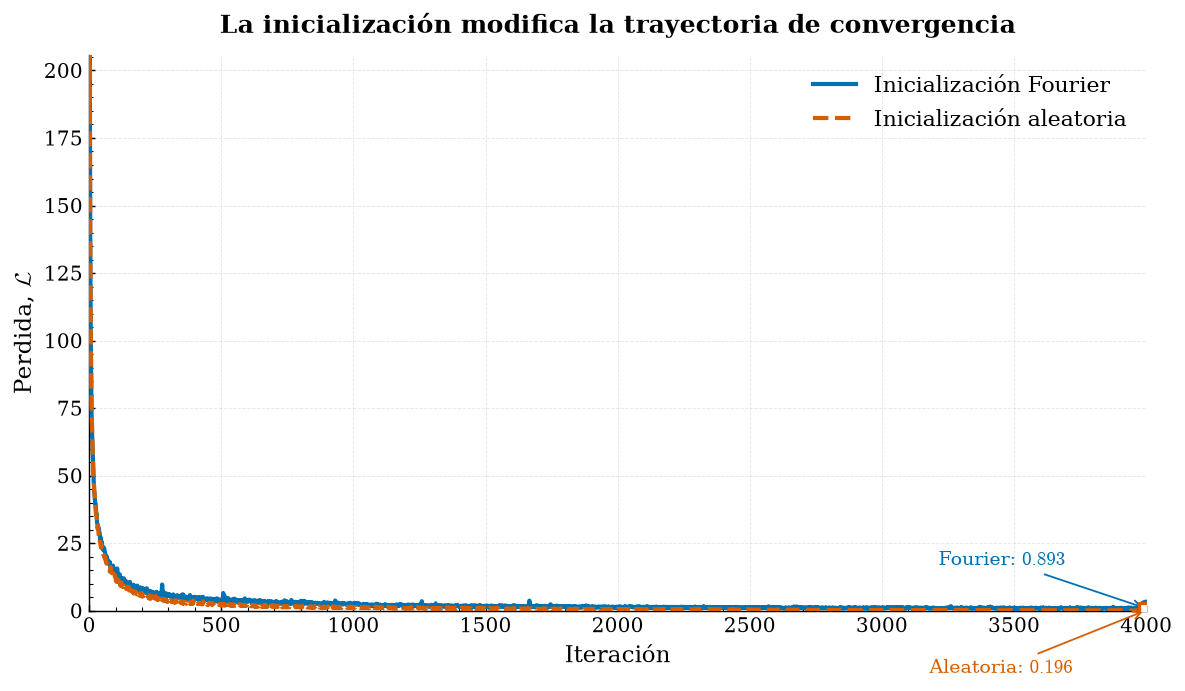

In [43]:
# Eje de iteraciones, incluyendo la iteración inicial 0
iteraciones = np.arange(N_ITER + 1)

# Colores con alto contraste y aptos para comparación
COLOR_FOURIER = "#0072B2"
COLOR_ALEATORIA = "#D55E00"
COLOR_REFERENCIA = "#5A5A5A"

fig, ax = plt.subplots(
    figsize=(9.0, 5.2),
    layout="constrained"
)

# Curva Fourier
ax.plot(
    iteraciones,
    historial_fourier["perdida"],
    color=COLOR_FOURIER,
    linewidth=2.3,
    linestyle="-",
    label="Inicialización Fourier",
    zorder=3
)

# Curva aleatoria
ax.plot(
    iteraciones,
    historial_aleatorio["perdida"],
    color=COLOR_ALEATORIA,
    linewidth=2.3,
    linestyle="--",
    label="Inicialización aleatoria",
    zorder=3
)

# Marcar los valores finales
ax.scatter(
    N_ITER,
    mse_final_fourier,
    color=COLOR_FOURIER,
    facecolor="white",
    linewidth=1.8,
    s=65,
    zorder=4
)

ax.scatter(
    N_ITER,
    mse_final_aleatoria,
    color=COLOR_ALEATORIA,
    facecolor="white",
    linewidth=1.8,
    s=65,
    marker="s",
    zorder=4
)

# Anotaciones finales
ax.annotate(
    rf"Fourier: ${mse_final_fourier:.3f}$",
    xy=(N_ITER, mse_final_fourier),
    xytext=(-115, 24),
    textcoords="offset points",
    color=COLOR_FOURIER,
    fontsize=10.5,
    arrowprops={
        "arrowstyle": "->",
        "color": COLOR_FOURIER,
        "linewidth": 1.0
    }
)

ax.annotate(
    rf"Aleatoria: ${mse_final_aleatoria:.3f}$",
    xy=(N_ITER, mse_final_aleatoria),
    xytext=(-120, -35),
    textcoords="offset points",
    color=COLOR_ALEATORIA,
    fontsize=10.5,
    arrowprops={
        "arrowstyle": "->",
        "color": COLOR_ALEATORIA,
        "linewidth": 1.0
    }
)

# Escala lineal: las pérdidas no abarcan varios órdenes de magnitud
ax.set_xlim(0, N_ITER)
ax.set_ylim(
    0,
    1.08 * max(
        historial_fourier["perdida"][0],
        historial_aleatorio["perdida"][0]
    )
)

ax.set_xlabel("Iteración")
ax.set_ylabel(r"Perdida, $\mathcal{L}$")

ax.set_title(
    "La inicialización modifica la trayectoria de convergencia",
    pad=12
)

ax.grid(
    True,
    which="major",
    color="#B0B0B0",
    linestyle="--",
    linewidth=0.5,
    alpha=0.30,
    zorder=0
)

ax.legend(
    loc="upper right",
    frameon=False
)

plt.show()

**Figura 3. Evolucion de la perdida durante el entrenamiento de las dos redes.**

Las curvas muestran la perdida $\mathcal{L}$ durante las 4000 iteraciones para
la inicializacion Fourier y la inicializacion aleatoria. Ambas redes fueron
entrenadas con la misma arquitectura, los mismos datos, la misma matriz inicial
$W_2$ y una tasa de aprendizaje $\eta=0.05$.

La unica diferencia experimental fue la inicializacion de $W_1$. Por tanto, las
diferencias observadas en la trayectoria de convergencia pueden atribuirse al
punto de partida de la primera capa.


In [44]:
# Curvas completas de perdida
perdidas_fourier = np.asarray(
    historial_fourier["perdida"]
)

perdidas_aleatorias = np.asarray(
    historial_aleatorio["perdida"]
)

# Diferencia: positiva cuando Fourier tiene mayor perdida
diferencia_perdidas = (
    perdidas_fourier
    -
    perdidas_aleatorias
)

# Buscar el primer paso de diferencia positiva a negativa
cruces = np.flatnonzero(
    (diferencia_perdidas[:-1] > 0)
    &
    (diferencia_perdidas[1:] <= 0)
)

if len(cruces) > 0:
    iteracion_cruce = int(cruces[0] + 1)

    fourier_permanece_mejor = np.all(
        perdidas_fourier[iteracion_cruce:]
        <=
        perdidas_aleatorias[iteracion_cruce:]
    )
else:
    iteracion_cruce = None
    fourier_permanece_mejor = False


# Diferencia relativa final: positiva si Fourier termina con mayor perdida
exceso_final_fourier = (
    (
        perdidas_fourier[-1]
        -
        perdidas_aleatorias[-1]
    )
    /
    perdidas_aleatorias[-1]
) * 100


print("Comparacion de convergencia")
print("-" * 55)

print(
    "Iteracion de cruce:",
    iteracion_cruce
    if iteracion_cruce is not None
    else "No se presento cruce"
)

print(
    "Fourier permanece por debajo despues del cruce:",
    fourier_permanece_mejor
)

print(
    f"Perdida final Fourier  : "
    f"{perdidas_fourier[-1]:.6f}"
)

print(
    f"Perdida final aleatoria: "
    f"{perdidas_aleatorias[-1]:.6f}"
)

print(
    f"Exceso final de perdida Fourier frente a aleatoria: "
    f"{exceso_final_fourier:.2f} %"
)


Comparacion de convergencia
-------------------------------------------------------
Iteracion de cruce: 2
Fourier permanece por debajo despues del cruce: False
Perdida final Fourier  : 0.892650
Perdida final aleatoria: 0.196131
Exceso final de perdida Fourier frente a aleatoria: 355.13 %


In [45]:
# Reconstrucciones finales de las dos redes
X_hat_fourier_final = np.asarray(
    reconstruir_senales(
        parametros_fourier_entrenados,
        X_jax
    )
)

X_hat_aleatoria_final = np.asarray(
    reconstruir_senales(
        parametros_aleatorios_entrenados,
        X_jax
    )
)

# Convertir las señales originales a NumPy
X_original = np.asarray(X_jax)

# Verificaciones
assert X_hat_fourier_final.shape == X_original.shape
assert X_hat_aleatoria_final.shape == X_original.shape

assert np.all(np.isfinite(X_hat_fourier_final))
assert np.all(np.isfinite(X_hat_aleatoria_final))

print(
    "Reconstrucciones finales calculadas correctamente."
)

Reconstrucciones finales calculadas correctamente.


In [46]:
# Obtener las señales originales y las reconstrucciones finales

# Señales originales como arreglo de NumPy
X_original = np.asarray(X_jax)

# Reconstrucción final con inicialización Fourier
X_hat_fourier_final = np.asarray(
    reconstruir_senales(
        parametros_fourier_entrenados,
        X_jax
    )
)

# Reconstrucción final con inicialización aleatoria
X_hat_aleatoria_final = np.asarray(
    reconstruir_senales(
        parametros_aleatorios_entrenados,
        X_jax
    )
)

# Verificar dimensiones
assert X_original.shape == (30, 256)
assert X_hat_fourier_final.shape == X_original.shape
assert X_hat_aleatoria_final.shape == X_original.shape

# Verificar que no existan NaN ni valores infinitos
assert np.all(np.isfinite(X_original))
assert np.all(np.isfinite(X_hat_fourier_final))
assert np.all(np.isfinite(X_hat_aleatoria_final))

print("Forma de X_original:", X_original.shape)
print("Forma reconstrucción Fourier:", X_hat_fourier_final.shape)
print("Forma reconstrucción aleatoria:", X_hat_aleatoria_final.shape)
print("Reconstrucciones finales calculadas correctamente.")

Forma de X_original: (30, 256)
Forma reconstrucción Fourier: (30, 256)
Forma reconstrucción aleatoria: (30, 256)
Reconstrucciones finales calculadas correctamente.


In [47]:
def seleccionar_senal_representativa(X, y, regimen):
    """
    Selecciona la señal cuya energía está más cerca
    de la energía mediana de su régimen.
    """
    indices = np.flatnonzero(
        y == regimen
    )

    if len(indices) == 0:
        raise ValueError(
            f"No existen señales del régimen {regimen}."
        )

    energias = np.mean(
        X[indices] ** 2,
        axis=1
    )

    energia_mediana = np.median(
        energias
    )

    posicion = np.argmin(
        np.abs(
            energias
            -
            energia_mediana
        )
    )

    return int(indices[posicion])


indices_representativos = {
    regimen: seleccionar_senal_representativa(
        X_original,
        y,
        regimen
    )
    for regimen in [0, 1, 2]
}

print("Señales representativas seleccionadas:")

for regimen, indice in indices_representativos.items():
    print(
        f"Régimen {regimen}: X[{indice}]"
    )

Señales representativas seleccionadas:
Régimen 0: X[8]
Régimen 1: X[25]
Régimen 2: X[18]


In [48]:
def error_relativo_senal(original, reconstruida):
    """
    Calcula el error relativo entre una señal original
    y su reconstrucción.
    """
    norma_original = np.linalg.norm(original)

    if norma_original == 0:
        return np.nan

    return (
        np.linalg.norm(reconstruida - original)
        / norma_original
    )


resultados_reconstruccion = []

for regimen in [0, 1, 2]:
    indice = indices_representativos[regimen]

    error_fourier = error_relativo_senal(
        X_original[indice],
        X_hat_fourier_final[indice]
    )

    error_aleatorio = error_relativo_senal(
        X_original[indice],
        X_hat_aleatoria_final[indice]
    )

    resultados_reconstruccion.append({
        "Régimen": regimen,
        "Índice": indice,
        "Error Fourier": error_fourier,
        "Error aleatorio": error_aleatorio
    })


print("Errores relativos de las señales seleccionadas")
print("-" * 70)

for resultado in resultados_reconstruccion:
    print(
        f"Régimen {resultado['Régimen']} | "
        f"X[{resultado['Índice']}] | "
        f"Fourier = {resultado['Error Fourier']:.4f} | "
        f"Aleatoria = {resultado['Error aleatorio']:.4f}"
    )

Errores relativos de las señales seleccionadas
----------------------------------------------------------------------
Régimen 0 | X[8] | Fourier = 0.1205 | Aleatoria = 0.0318
Régimen 1 | X[25] | Fourier = 0.0168 | Aleatoria = 0.0133
Régimen 2 | X[18] | Fourier = 0.0213 | Aleatoria = 0.0226


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


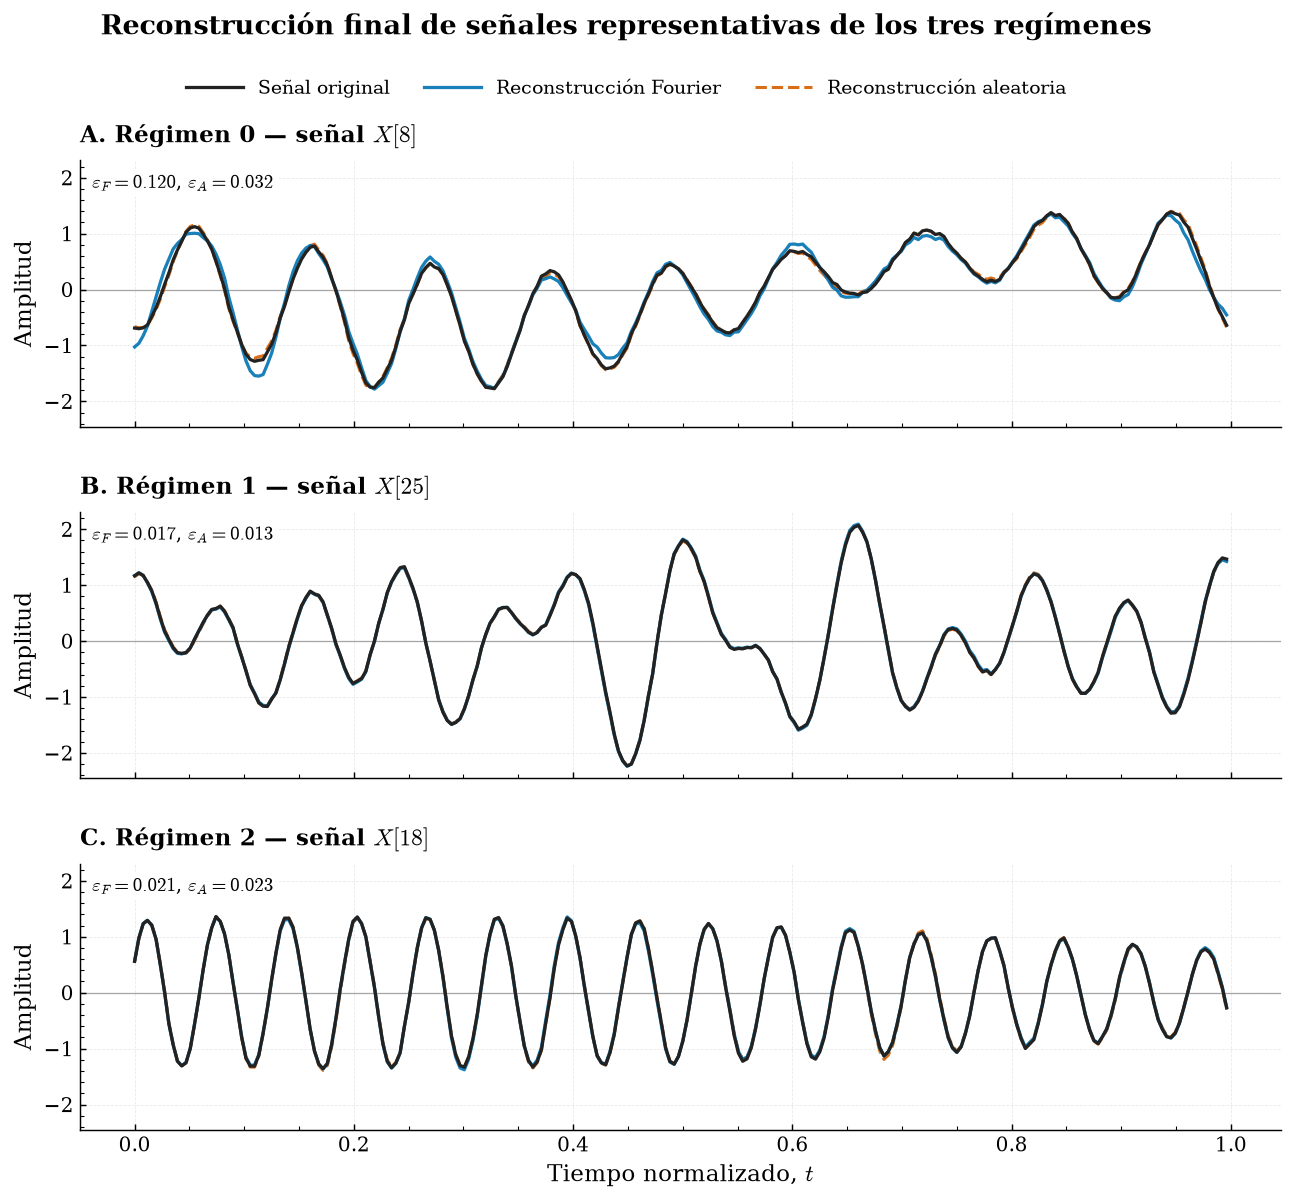

In [49]:
# Figura con una señal representativa por régimen
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(10.5, 9.5),
    sharex=True,
sharey=True
)

letras_panel = ["A", "B", "C"]

for ax, regimen, letra in zip(
    axes,
    [0, 1, 2],
    letras_panel
):
    indice = indices_representativos[regimen]

    error_fourier = error_relativo_senal(
        X_original[indice],
        X_hat_fourier_final[indice]
    )

    error_aleatorio = error_relativo_senal(
        X_original[indice],
        X_hat_aleatoria_final[indice]
    )

    # Señal original
    ax.plot(
        t,
        X_original[indice],
        color="#222222",
        linewidth=1.8,
        label="Señal original",
        zorder=4
    )

    # Reconstrucción Fourier
    ax.plot(
        t,
        X_hat_fourier_final[indice],
        color=COLOR_FOURIER,
        linewidth=1.8,
        linestyle="-",
        alpha=0.90,
        label="Reconstrucción Fourier",
        zorder=3
    )

    # Reconstrucción aleatoria
    ax.plot(
        t,
        X_hat_aleatoria_final[indice],
        color=COLOR_ALEATORIA,
        linewidth=1.7,
        linestyle="--",
        alpha=0.90,
        label="Reconstrucción aleatoria",
        zorder=2
    )

    # Línea de referencia
    ax.axhline(
        0,
        color=COLOR_REFERENCIA,
        linewidth=0.7,
        alpha=0.55,
        zorder=1
    )

    ax.set_ylabel("Amplitud")

    # Título del panel
    ax.set_title(
        rf"{letra}. Régimen {regimen} — señal $X[{indice}]$",
        loc="left",
        fontsize=13,
        fontweight="semibold",
        pad=10
    )

    # Errores dentro del panel, separados del título
    ax.text(
        0.01,
        0.95,
        rf"$\varepsilon_F={error_fourier:.3f}$, "
        rf"$\varepsilon_A={error_aleatorio:.3f}$",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10.5,
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.80,
            "pad": 2.5
        },
        zorder=6
    )

    ax.grid(
        True,
        which="major",
        color="#B0B0B0",
        linestyle="--",
        linewidth=0.45,
        alpha=0.28,
        zorder=0
    )

# Etiqueta del eje horizontal
axes[-1].set_xlabel(r"Tiempo normalizado, $t$")

# Obtener una única leyenda
handles, labels = axes[0].get_legend_handles_labels()

# Título general
fig.suptitle(
    "Reconstrucción final de señales representativas "
    "de los tres regímenes",
    fontsize=15,
    fontweight="semibold",
    y=0.985
)

# Leyenda general debajo del título y fuera de los paneles
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.945),
    ncol=3,
    frameon=False,
    fontsize=10.5,
    handlelength=3.0,
    columnspacing=1.8
)

# Reservar espacio para título y leyenda
fig.subplots_adjust(
    top=0.865,
    bottom=0.08,
    left=0.10,
    right=0.98,
    hspace=0.32
)

plt.show()

**Figura 4. Reconstrucciones finales para señales representativas de los tres regímenes.**

En cada panel se compara la señal original con las reconstrucciones producidas por
las redes inicializadas mediante Fourier y mediante pesos aleatorios.

Para evitar seleccionar únicamente casos favorables, la señal mostrada en cada
régimen fue escogida como aquella cuya energía se encuentra más cerca de la
energía mediana del régimen.

Los valores $\varepsilon_F$ y $\varepsilon_A$ corresponden al error relativo de
las reconstrucciones Fourier y aleatoria, respectivamente:

$$
\varepsilon_r
=
\frac{\|\hat{x}-x\|_2}
{\|x\|_2}.
$$

Una reconstrucción es mejor cuanto más cerca sigue la forma de la señal original
y cuanto menor es su error relativo.

In [50]:
# Norma de cada señal original
normas_originales = np.linalg.norm(
    X_original,
    axis=1
)

# Error relativo de cada señal con inicialización Fourier
errores_fourier_todos = (
    np.linalg.norm(
        X_hat_fourier_final - X_original,
        axis=1
    )
    / normas_originales
)

# Error relativo de cada señal con inicialización aleatoria
errores_aleatorios_todos = (
    np.linalg.norm(
        X_hat_aleatoria_final - X_original,
        axis=1
    )
    / normas_originales
)

# Verificaciones
assert errores_fourier_todos.shape == (30,)
assert errores_aleatorios_todos.shape == (30,)

assert np.all(np.isfinite(errores_fourier_todos))
assert np.all(np.isfinite(errores_aleatorios_todos))

print("Errores relativos individuales calculados correctamente.")

Errores relativos individuales calculados correctamente.


In [51]:
import pandas as pd

resumen_regimenes = []

for regimen in [0, 1, 2]:
    indices = np.flatnonzero(y == regimen)

    errores_f = errores_fourier_todos[indices]
    errores_a = errores_aleatorios_todos[indices]

    media_f = np.mean(errores_f)
    media_a = np.mean(errores_a)

    ventaja_fourier = (
        (media_a - media_f)
        / media_a
    ) * 100

    resumen_regimenes.append({
        "Régimen": regimen,
        "N.º de señales": len(indices),

        "Media Fourier": media_f,
        "Desv. Fourier": np.std(errores_f, ddof=1),
        "Mediana Fourier": np.median(errores_f),

        "Media aleatoria": media_a,
        "Desv. aleatoria": np.std(errores_a, ddof=1),
        "Mediana aleatoria": np.median(errores_a),

        "Ventaja Fourier (%)": ventaja_fourier
    })

tabla_regimenes = pd.DataFrame(
    resumen_regimenes
)

display(
    tabla_regimenes.style.format({
        "Media Fourier": "{:.4f}",
        "Desv. Fourier": "{:.4f}",
        "Mediana Fourier": "{:.4f}",
        "Media aleatoria": "{:.4f}",
        "Desv. aleatoria": "{:.4f}",
        "Mediana aleatoria": "{:.4f}",
        "Ventaja Fourier (%)": "{:.2f}"
    })
)

,Régimen,N.º de señales,Media Fourier,Desv. Fourier,Mediana Fourier,Media aleatoria,Desv. aleatoria,Mediana aleatoria,Ventaja Fourier (%)
0,0,10,0.0485,0.0291,0.0414,0.0351,0.0152,0.0398,-37.98
1,1,10,0.0578,0.0318,0.0484,0.0305,0.0211,0.0246,-89.74
2,2,10,0.0742,0.0711,0.0399,0.0342,0.0215,0.0232,-116.81


In [52]:
# Régimen con mayor error medio para cada inicialización
regimen_dificil_fourier = int(
    tabla_regimenes.loc[
        tabla_regimenes["Media Fourier"].idxmax(),
        "Régimen"
    ]
)

regimen_dificil_aleatorio = int(
    tabla_regimenes.loc[
        tabla_regimenes["Media aleatoria"].idxmax(),
        "Régimen"
    ]
)

print(
    "Régimen con mayor error medio usando Fourier:",
    regimen_dificil_fourier
)

print(
    "Régimen con mayor error medio usando inicialización aleatoria:",
    regimen_dificil_aleatorio
)

print(
    "Régimen asignado para análisis detallado:",
    REGIMEN_FOCO
)

Régimen con mayor error medio usando Fourier: 2
Régimen con mayor error medio usando inicialización aleatoria: 0
Régimen asignado para análisis detallado: 2


### Comparacion final entre regimenes

Con la escala corregida, ambas inicializaciones logran errores relativos bajos.
La inicializacion aleatoria termino con menor error medio en los tres regimenes,
aunque el regimen con mayor error no fue el mismo para las dos redes.

Para el regimen $0$, los errores medios fueron:

$$
\overline{\varepsilon}_{F,0}=0.0485,
\qquad
\overline{\varepsilon}_{A,0}=0.0351.
$$

Para el regimen $1$:

$$
\overline{\varepsilon}_{F,1}=0.0578,
\qquad
\overline{\varepsilon}_{A,1}=0.0305.
$$

Para el regimen $2$:

$$
\overline{\varepsilon}_{F,2}=0.0742,
\qquad
\overline{\varepsilon}_{A,2}=0.0342.
$$

Con inicializacion Fourier, el mayor error medio aparece en el regimen $2$, que
es el regimen foco asignado. Con inicializacion aleatoria, el mayor error medio
aparece en el regimen $0$, aunque las diferencias entre regimenes quedan en un
rango bajo.

Aunque la inicializacion Fourier evita la saturacion inicial de la no linealidad,
la inicializacion aleatoria escalada ofrecio una trayectoria de optimizacion mas
favorable en esta ejecucion concreta.


Este resultado es coherente con la fisica del regimen foco. Para $\mu=15$ y
$k=1,\ldots,11$, las frecuencias del medio son

$$
\omega(k)=\sqrt{k^2+15^2}\in[15.03,18.60].
$$

Es decir, muchas componentes quedan por encima de la ultima frecuencia entera de
la base usada en la capa, $k=15$, y ademas no coinciden exactamente con
frecuencias enteras. Esa desalineacion produce fuga espectral: la energia de una
componente fisica se reparte entre varios coeficientes de Fourier. Por eso el
regimen $2$ es el mas exigente para una base Fourier truncada a $K=15$.


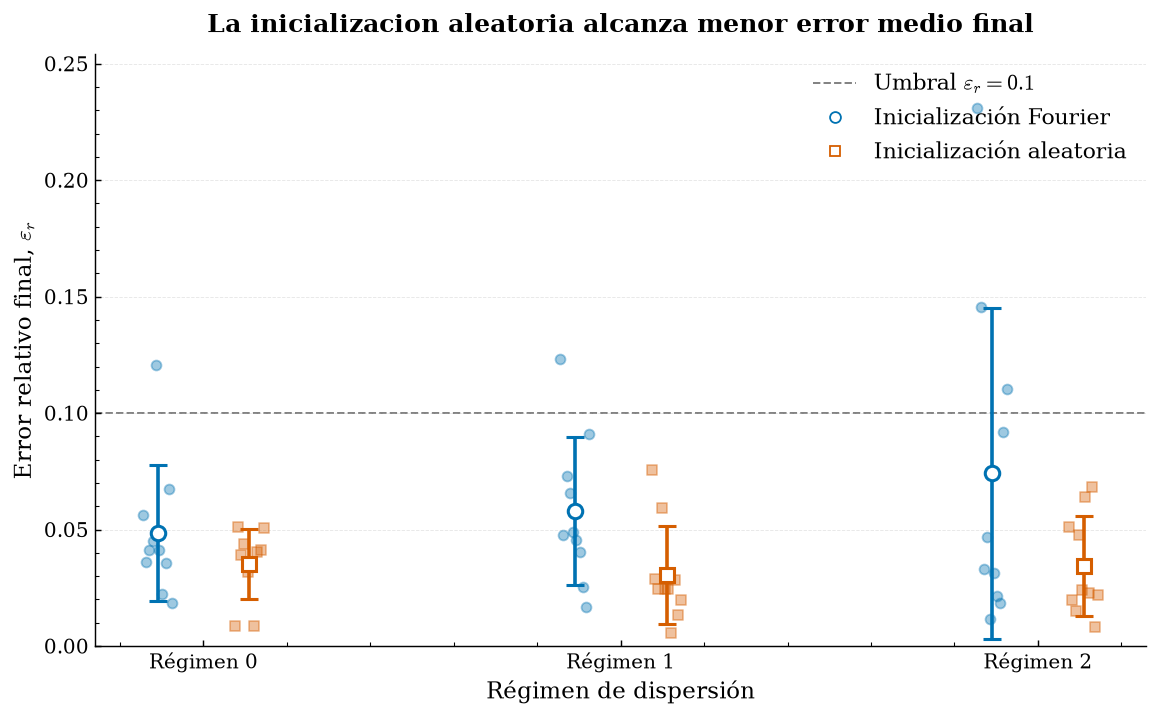

In [53]:
# Posiciones de los tres regímenes
regimenes = np.array([0, 1, 2])
desplazamiento = 0.11

fig, ax = plt.subplots(
    figsize=(8.8, 5.4),
    layout="constrained"
)

for regimen in regimenes:
    indices = np.flatnonzero(y == regimen)

    errores_f = errores_fourier_todos[indices]
    errores_a = errores_aleatorios_todos[indices]

    # Pequeña separación horizontal determinista
    separacion = np.linspace(
        -0.035,
        0.035,
        len(indices)
    )

    # Errores individuales Fourier
    ax.scatter(
        regimen - desplazamiento + separacion,
        errores_f,
        color=COLOR_FOURIER,
        alpha=0.38,
        s=30,
        marker="o",
        zorder=2
    )

    # Errores individuales aleatorios
    ax.scatter(
        regimen + desplazamiento + separacion,
        errores_a,
        color=COLOR_ALEATORIA,
        alpha=0.38,
        s=30,
        marker="s",
        zorder=2
    )

    # Media y desviación estándar Fourier
    ax.errorbar(
        regimen - desplazamiento,
        np.mean(errores_f),
        yerr=np.std(errores_f, ddof=1),
        color=COLOR_FOURIER,
        marker="o",
        markersize=8,
        markerfacecolor="white",
        markeredgewidth=1.7,
        capsize=5,
        linewidth=2,
        zorder=4
    )

    # Media y desviación estándar aleatoria
    ax.errorbar(
        regimen + desplazamiento,
        np.mean(errores_a),
        yerr=np.std(errores_a, ddof=1),
        color=COLOR_ALEATORIA,
        marker="s",
        markersize=8,
        markerfacecolor="white",
        markeredgewidth=1.7,
        capsize=5,
        linewidth=2,
        zorder=4
    )

# Umbral exigido
ax.axhline(
    UMBRAL_ERROR,
    color=COLOR_REFERENCIA,
    linestyle="--",
    linewidth=1.1,
    alpha=0.75,
    label=r"Umbral $\varepsilon_r=0.1$",
    zorder=1
)

# Elementos auxiliares para la leyenda
ax.plot(
    [],
    [],
    color=COLOR_FOURIER,
    marker="o",
    linestyle="",
    markerfacecolor="white",
    label="Inicialización Fourier"
)

ax.plot(
    [],
    [],
    color=COLOR_ALEATORIA,
    marker="s",
    linestyle="",
    markerfacecolor="white",
    label="Inicialización aleatoria"
)

ax.set_xticks(regimenes)
ax.set_xticklabels([
    "Régimen 0",
    "Régimen 1",
    "Régimen 2"
])

ax.set_xlabel("Régimen de dispersión")
ax.set_ylabel(r"Error relativo final, $\varepsilon_r$")

ax.set_title(
    "La inicializacion aleatoria alcanza menor error medio final",
    pad=12
)

ax.set_ylim(
    0,
    1.10 * max(
        errores_fourier_todos.max(),
        errores_aleatorios_todos.max()
    )
)

ax.grid(
    True,
    axis="y",
    color="#B0B0B0",
    linestyle="--",
    linewidth=0.5,
    alpha=0.30,
    zorder=0
)

ax.legend(
    loc="upper right",
    frameon=False
)

plt.show()

**Figura 5. Distribucion del error relativo final en los tres regimenes.**

Los puntos semitransparentes representan los errores individuales de las diez
senales de cada regimen. Los marcadores grandes indican el error medio y las
barras verticales representan una desviacion estandar.

El error relativo medio de ambas inicializaciones bajo del umbral
$\varepsilon_r=0.1$ dentro de las 4000 iteraciones. Al final del entrenamiento,
la inicializacion aleatoria presento menor error medio que Fourier en los tres
regimenes.

Para la red Fourier, el regimen $2$ presento el mayor error promedio. Para la
red aleatoria, el mayor error promedio fue el del regimen $0$.


In [54]:
# Señales pertenecientes al régimen asignado
mascara_regimen_foco = (y == REGIMEN_FOCO)

X_foco_jax = X_jax[mascara_regimen_foco]

print("Régimen de análisis:", REGIMEN_FOCO)
print("Forma de X_foco_jax:", X_foco_jax.shape)

assert X_foco_jax.shape == (10, 256)

Régimen de análisis: 2
Forma de X_foco_jax: (10, 256)


In [55]:
def entrenar_con_seguimiento_foco(
    parametros_iniciales,
    X_entrenamiento,
    X_foco,
    numero_iteraciones,
    tasa_aprendizaje,
    nombre_modelo
):
    """
    Entrena sobre todo el dataset y registra, en cada iteración,
    el desempeño global y el desempeño del régimen foco.
    """

    parametros = jax.tree_util.tree_map(
        lambda arreglo: jnp.array(arreglo),
        parametros_iniciales
    )

    historia_global = np.empty(numero_iteraciones + 1)
    historia_foco = np.empty(numero_iteraciones + 1)

    eta_jax = jnp.asarray(
        tasa_aprendizaje,
        dtype=jnp.float64
    )

    # Iteración 0
    historia_global[0] = float(
        error_relativo_medio(
            parametros,
            X_entrenamiento
        )
    )

    historia_foco[0] = float(
        error_relativo_medio(
            parametros,
            X_foco
        )
    )

    print(f"Seguimiento del régimen {REGIMEN_FOCO}: {nombre_modelo}")
    print("-" * 68)

    print(
        f"Iteración {0:4d} | "
        f"Error global = {historia_global[0]:.6f} | "
        f"Error régimen {REGIMEN_FOCO} = {historia_foco[0]:.6f}"
    )

    for iteracion in range(1, numero_iteraciones + 1):

        # Los parámetros se actualizan usando las 30 señales
        parametros, _ = paso_descenso_gradiente(
            parametros,
            X_entrenamiento,
            eta_jax
        )

        # Métricas globales
        historia_global[iteracion] = float(
            error_relativo_medio(
                parametros,
                X_entrenamiento
            )
        )

        # Métricas exclusivamente del régimen foco
        historia_foco[iteracion] = float(
            error_relativo_medio(
                parametros,
                X_foco
            )
        )

        if not np.isfinite(historia_foco[iteracion]):
            raise FloatingPointError(
                f"El modelo {nombre_modelo} presentó "
                f"inestabilidad en la iteración {iteracion}."
            )

        if iteracion % 500 == 0:
            print(
                f"Iteración {iteracion:4d} | "
                f"Error global = {historia_global[iteracion]:.6f} | "
                f"Error régimen {REGIMEN_FOCO} = "
                f"{historia_foco[iteracion]:.6f}"
            )

    historial = {
        "error_global_medio": historia_global,
        "error_foco_medio": historia_foco
    }

    return parametros, historial

In [56]:
_, historial_foco_fourier = entrenar_con_seguimiento_foco(
    parametros_iniciales=parametros_fourier,
    X_entrenamiento=X_jax,
    X_foco=X_foco_jax,
    numero_iteraciones=N_ITER,
    tasa_aprendizaje=ETA,
    nombre_modelo="Inicialización Fourier"
)

Seguimiento del régimen 2: Inicialización Fourier
--------------------------------------------------------------------
Iteración    0 | Error global = 1.021368 | Error régimen 2 = 1.007772


Iteración  500 | Error global = 0.142855 | Error régimen 2 = 0.153081


Iteración 1000 | Error global = 0.100863 | Error régimen 2 = 0.116357


Iteración 1500 | Error global = 0.086089 | Error régimen 2 = 0.119755


Iteración 2000 | Error global = 0.074794 | Error régimen 2 = 0.096071
Iteración 2500 | Error global = 0.070098 | Error régimen 2 = 0.097086


Iteración 3000 | Error global = 0.067770 | Error régimen 2 = 0.084965
Iteración 3500 | Error global = 0.062271 | Error régimen 2 = 0.087741


Iteración 4000 | Error global = 0.060164 | Error régimen 2 = 0.074174


In [57]:
_, historial_foco_aleatorio = entrenar_con_seguimiento_foco(
    parametros_iniciales=parametros_aleatorios,
    X_entrenamiento=X_jax,
    X_foco=X_foco_jax,
    numero_iteraciones=N_ITER,
    tasa_aprendizaje=ETA,
    nombre_modelo="Inicialización aleatoria"
)

Seguimiento del régimen 2: Inicialización aleatoria
--------------------------------------------------------------------
Iteración    0 | Error global = 1.004195 | Error régimen 2 = 1.007529
Iteración  500 | Error global = 0.110163 | Error régimen 2 = 0.117926


Iteración 1000 | Error global = 0.077760 | Error régimen 2 = 0.089375
Iteración 1500 | Error global = 0.070977 | Error régimen 2 = 0.088480


Iteración 2000 | Error global = 0.057966 | Error régimen 2 = 0.058883
Iteración 2500 | Error global = 0.050021 | Error régimen 2 = 0.057921


Iteración 3000 | Error global = 0.038741 | Error régimen 2 = 0.036707


Iteración 3500 | Error global = 0.036664 | Error régimen 2 = 0.038423
Iteración 4000 | Error global = 0.033277 | Error régimen 2 = 0.034211


In [58]:
# Curvas del error relativo medio del regimen foco
error_foco_fourier = np.asarray(
    historial_foco_fourier["error_foco_medio"]
)

error_foco_aleatorio = np.asarray(
    historial_foco_aleatorio["error_foco_medio"]
)

iteraciones = np.arange(N_ITER + 1)

# Diferencia entre las dos curvas:
# negativa -> Fourier tiene menor error
# positiva -> la inicializacion aleatoria tiene menor error
diferencia_foco = (
    error_foco_fourier
    -
    error_foco_aleatorio
)

# Detectar cambios de signo sin saturar la salida con una lista larga
iteraciones_cruce = np.flatnonzero(
    np.signbit(diferencia_foco[:-1])
    !=
    np.signbit(diferencia_foco[1:])
) + 1

numero_cruces_foco = len(iteraciones_cruce)
primer_cruce_foco = (
    int(iteraciones_cruce[0])
    if numero_cruces_foco > 0
    else None
)
ultimo_cruce_foco = (
    int(iteraciones_cruce[-1])
    if numero_cruces_foco > 0
    else None
)

# Iteracion en que cada curva baja del umbral principal
indices_umbral_foco_fourier = np.flatnonzero(
    error_foco_fourier < UMBRAL_ERROR
)

indices_umbral_foco_aleatoria = np.flatnonzero(
    error_foco_aleatorio < UMBRAL_ERROR
)

iter_foco_umbral_fourier = (
    int(indices_umbral_foco_fourier[0])
    if len(indices_umbral_foco_fourier) > 0
    else None
)

iter_foco_umbral_aleatoria = (
    int(indices_umbral_foco_aleatoria[0])
    if len(indices_umbral_foco_aleatoria) > 0
    else None
)

# Reduccion total del error
reduccion_foco_fourier = (
    1
    -
    error_foco_fourier[-1]
    /
    error_foco_fourier[0]
) * 100

reduccion_foco_aleatoria = (
    1
    -
    error_foco_aleatorio[-1]
    /
    error_foco_aleatorio[0]
) * 100

# Diferencia relativa final: positiva si Fourier termina con mayor error
exceso_final_fourier_foco = (
    (
        error_foco_fourier[-1]
        -
        error_foco_aleatorio[-1]
    )
    /
    error_foco_aleatorio[-1]
) * 100

print("Analisis de convergencia del regimen foco")
print("-" * 62)

print(
    "Numero de cambios de inicializacion con menor error:",
    numero_cruces_foco
)

print(
    "Primer cambio:",
    primer_cruce_foco
    if primer_cruce_foco is not None
    else "No se presento cruce"
)

print(
    "Ultimo cambio:",
    ultimo_cruce_foco
    if ultimo_cruce_foco is not None
    else "No se presento cruce"
)

print(
    f"Error inicial Fourier   : "
    f"{error_foco_fourier[0]:.6f}"
)

print(
    f"Error inicial aleatoria : "
    f"{error_foco_aleatorio[0]:.6f}"
)

print(
    f"Error final Fourier     : "
    f"{error_foco_fourier[-1]:.6f}"
)

print(
    f"Error final aleatoria   : "
    f"{error_foco_aleatorio[-1]:.6f}"
)

print(
    "Primera iteracion bajo 0.1 - Fourier:",
    iter_foco_umbral_fourier
    if iter_foco_umbral_fourier is not None
    else "No alcanzado"
)

print(
    "Primera iteracion bajo 0.1 - aleatoria:",
    iter_foco_umbral_aleatoria
    if iter_foco_umbral_aleatoria is not None
    else "No alcanzado"
)

print(
    f"Reduccion Fourier       : "
    f"{reduccion_foco_fourier:.2f} %"
)

print(
    f"Reduccion aleatoria     : "
    f"{reduccion_foco_aleatoria:.2f} %"
)

print(
    f"Exceso final de error Fourier frente a aleatoria: "
    f"{exceso_final_fourier_foco:.2f} %"
)


Analisis de convergencia del regimen foco
--------------------------------------------------------------
Numero de cambios de inicializacion con menor error: 140
Primer cambio: 1
Ultimo cambio: 1142
Error inicial Fourier   : 1.007772
Error inicial aleatoria : 1.007529
Error final Fourier     : 0.074174
Error final aleatoria   : 0.034211
Primera iteracion bajo 0.1 - Fourier: 1149
Primera iteracion bajo 0.1 - aleatoria: 639
Reduccion Fourier       : 92.64 %
Reduccion aleatoria     : 96.60 %
Exceso final de error Fourier frente a aleatoria: 116.81 %


In [59]:
def primera_iteracion_bajo_valor(curva, umbral):
    """
    Retorna la primera iteración en que la curva
    queda estrictamente por debajo del umbral.
    """
    indices = np.flatnonzero(
        np.asarray(curva) < umbral
    )

    if len(indices) == 0:
        return None

    return int(indices[0])


umbrales_comparacion = [UMBRAL_ERROR, 0.75, 0.60, 0.50]
filas_velocidad = []

for umbral in umbrales_comparacion:
    iter_f = primera_iteracion_bajo_valor(
        error_foco_fourier,
        umbral
    )

    iter_a = primera_iteracion_bajo_valor(
        error_foco_aleatorio,
        umbral
    )

    filas_velocidad.append({
        "Umbral de error": umbral,
        "Iteración Fourier": (
            iter_f if iter_f is not None else "No alcanzado"
        ),
        "Iteración aleatoria": (
            iter_a if iter_a is not None else "No alcanzado"
        )
    })

tabla_velocidad_foco = pd.DataFrame(
    filas_velocidad
)

display(tabla_velocidad_foco)

,Umbral de error,Iteración Fourier,Iteración aleatoria
0,0.10,1149,639
1,0.75,6,6
2,0.60,9,12
3,0.50,18,19


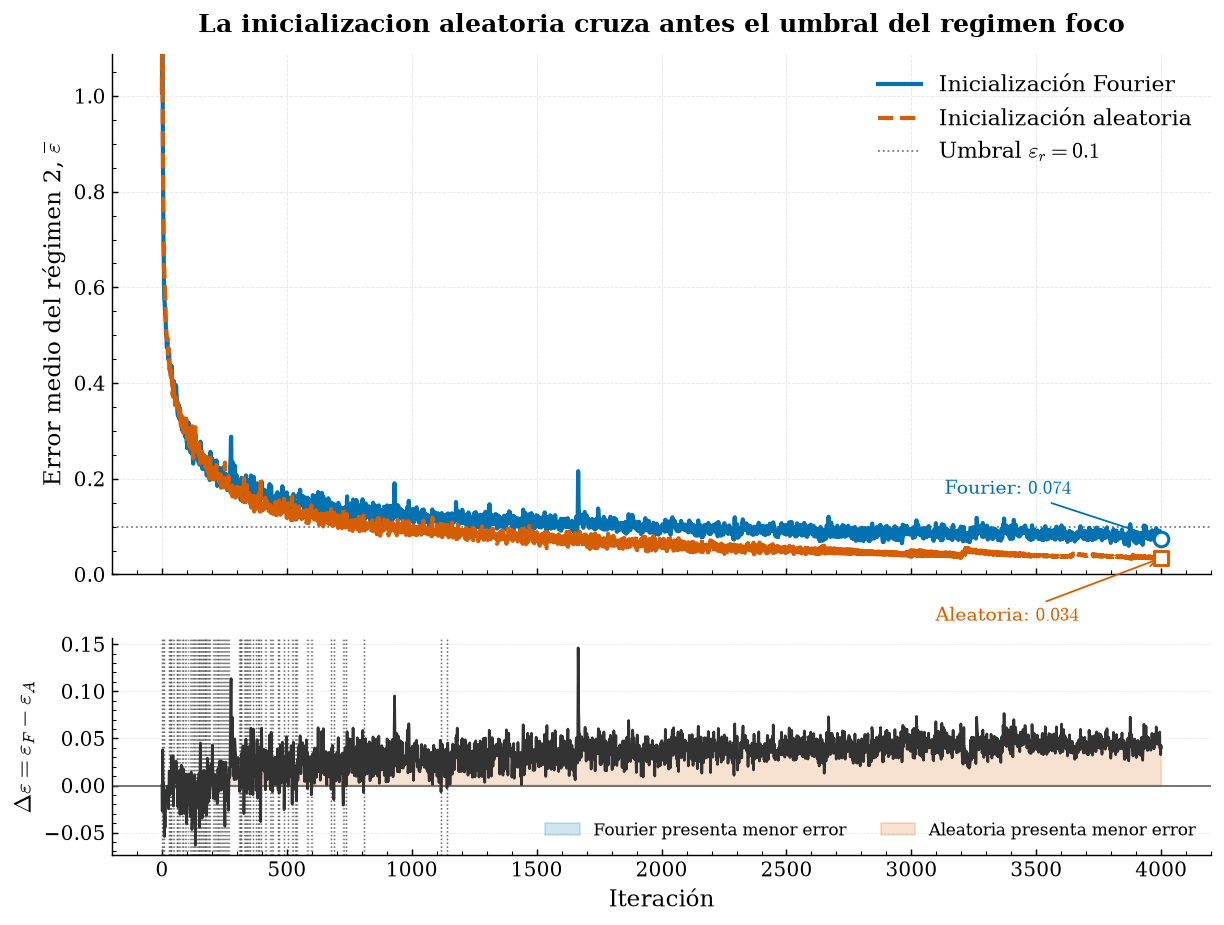

In [60]:
fig, (ax_error, ax_diferencia) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(9.3, 7.0),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3.0, 1.25]
    },
    layout="constrained"
)

# =========================================================
# Panel A: errores del régimen foco
# =========================================================

ax_error.plot(
    iteraciones,
    error_foco_fourier,
    color=COLOR_FOURIER,
    linewidth=2.3,
    linestyle="-",
    label="Inicialización Fourier",
    zorder=3
)

ax_error.plot(
    iteraciones,
    error_foco_aleatorio,
    color=COLOR_ALEATORIA,
    linewidth=2.3,
    linestyle="--",
    label="Inicialización aleatoria",
    zorder=3
)

# Umbral exigido por la rúbrica
ax_error.axhline(
    UMBRAL_ERROR,
    color=COLOR_REFERENCIA,
    linewidth=1.0,
    linestyle=":",
    alpha=0.80,
    label=r"Umbral $\varepsilon_r=0.1$",
    zorder=1
)

# Marcar valores finales
ax_error.scatter(
    N_ITER,
    error_foco_fourier[-1],
    facecolor="white",
    edgecolor=COLOR_FOURIER,
    linewidth=1.7,
    s=65,
    zorder=4
)

ax_error.scatter(
    N_ITER,
    error_foco_aleatorio[-1],
    facecolor="white",
    edgecolor=COLOR_ALEATORIA,
    linewidth=1.7,
    s=65,
    marker="s",
    zorder=4
)

ax_error.annotate(
    rf"Fourier: ${error_foco_fourier[-1]:.3f}$",
    xy=(N_ITER, error_foco_fourier[-1]),
    xytext=(-120, 25),
    textcoords="offset points",
    color=COLOR_FOURIER,
    fontsize=10.5,
    arrowprops={
        "arrowstyle": "->",
        "color": COLOR_FOURIER,
        "linewidth": 1.0
    }
)

ax_error.annotate(
    rf"Aleatoria: ${error_foco_aleatorio[-1]:.3f}$",
    xy=(N_ITER, error_foco_aleatorio[-1]),
    xytext=(-125, -35),
    textcoords="offset points",
    color=COLOR_ALEATORIA,
    fontsize=10.5,
    arrowprops={
        "arrowstyle": "->",
        "color": COLOR_ALEATORIA,
        "linewidth": 1.0
    }
)

ax_error.set_ylabel(
    rf"Error medio del régimen {REGIMEN_FOCO}, "
    r"$\overline{\varepsilon}$"
)

ax_error.set_ylim(
    0,
    1.08 * max(
        error_foco_fourier[0],
        error_foco_aleatorio[0]
    )
)

ax_error.set_title(
    "La inicializacion aleatoria cruza antes el umbral del regimen foco",
    pad=12
)

ax_error.grid(
    True,
    which="major",
    color="#B0B0B0",
    linestyle="--",
    linewidth=0.5,
    alpha=0.30,
    zorder=0
)

ax_error.legend(
    loc="upper right",
    frameon=False
)

# =========================================================
# Panel B: diferencia entre las curvas
# =========================================================

ax_diferencia.plot(
    iteraciones,
    diferencia_foco,
    color="#333333",
    linewidth=1.5,
    zorder=3
)

ax_diferencia.axhline(
    0,
    color=COLOR_REFERENCIA,
    linewidth=0.9,
    zorder=2
)

# Región donde Fourier tiene menor error
ax_diferencia.fill_between(
    iteraciones,
    diferencia_foco,
    0,
    where=(diferencia_foco <= 0),
    color=COLOR_FOURIER,
    alpha=0.18,
    interpolate=True,
    label="Fourier presenta menor error"
)

# Región donde la aleatoria tiene menor error
ax_diferencia.fill_between(
    iteraciones,
    diferencia_foco,
    0,
    where=(diferencia_foco > 0),
    color=COLOR_ALEATORIA,
    alpha=0.18,
    interpolate=True,
    label="Aleatoria presenta menor error"
)

# Señalar las iteraciones de cruce
for iteracion_cruce in iteraciones_cruce:
    ax_diferencia.axvline(
        iteracion_cruce,
        color=COLOR_REFERENCIA,
        linestyle=":",
        linewidth=0.8,
        alpha=0.65
    )

ax_diferencia.set_xlabel("Iteración")

ax_diferencia.set_ylabel(
    r"$\Delta\varepsilon="
    r"\varepsilon_F-\varepsilon_A$"
)

ax_diferencia.grid(
    True,
    axis="y",
    color="#B0B0B0",
    linestyle="--",
    linewidth=0.45,
    alpha=0.28,
    zorder=0
)

ax_diferencia.legend(
    loc="best",
    frameon=False,
    fontsize=9.5,
    ncol=2
)

plt.show()

**Figura 6. Velocidad de convergencia para las senales del regimen foco $2$.**

El panel superior muestra la evolucion del error relativo medio de las diez
senales pertenecientes al regimen $2$. Los parametros de ambas redes se
actualizaron utilizando las 30 senales del conjunto completo; el error del
regimen foco se registro separadamente despues de cada actualizacion.

El panel inferior muestra la diferencia:

$$
\Delta\varepsilon
=
\varepsilon_F-\varepsilon_A.
$$

Las regiones azules corresponden a intervalos donde la inicializacion Fourier
presento menor error, mientras que las regiones naranjas corresponden a
intervalos donde la inicializacion aleatoria presento menor error.

En este regimen, ambas inicializaciones bajaron de $\varepsilon_r=0.1$. La red
aleatoria alcanzo ese umbral en la iteracion 639, mientras que la red Fourier lo
alcanzo en la iteracion 1149. Al final del entrenamiento, los errores medios del
regimen foco fueron $0.0742$ para Fourier y $0.0342$ para la inicializacion
aleatoria.

El regimen $2$ es dificil para una base Fourier truncada porque sus frecuencias
fisicas no son enteras y se ubican aproximadamente entre $15.03$ y $18.60$; por
eso varias componentes quedan fuera o cerca del borde de la base disponible
$k=1,\ldots,15$.


# Parte V - Compresion mediante coeficientes Fourier

La base Fourier normalizada utilizada para la compresion tiene filas
aproximadamente ortonormales. Para una senal $x$, sus coeficientes se calculan
mediante:

$$
c=Qx,
$$

donde:

$$
Q=\sqrt{\frac{2}{N}}W_{\mathrm{Fourier}}
\in\mathbb{R}^{30\times256}.
$$

Los primeros 15 coeficientes corresponden a cosenos y los siguientes 15 a
senos. Para cada frecuencia $k$, la energia del modo se define como:

$$
E_k=c_{\cos,k}^{\,2}+c_{\sin,k}^{\,2}.
$$

Para comprimir una senal se conservan primero los modos con mayor energia y se
anulan los restantes. La reconstruccion comprimida se calcula mediante:

$$
\hat{x}_m=Q^{\mathsf T}c_m,
$$

donde $c_m$ contiene unicamente los coeficientes conservados.


In [61]:
# Base Fourier normalizada utilizada para la compresión
Q_fourier = np.asarray(W1_fourier_inicial)

# Coeficientes Fourier de las 30 señales
# X: (30, 256), Q.T: (256, 30)
coeficientes_fourier = X_original @ Q_fourier.T

print("Forma de Q_fourier:", Q_fourier.shape)
print("Forma de los coeficientes:", coeficientes_fourier.shape)

# Separar cosenos y senos
coef_cos = coeficientes_fourier[:, :K]
coef_sin = coeficientes_fourier[:, K:]

assert Q_fourier.shape == (2 * K, 256)
assert coeficientes_fourier.shape == (30, 2 * K)
assert coef_cos.shape == (30, K)
assert coef_sin.shape == (30, K)

print("Coeficientes Fourier calculados correctamente.")

Forma de Q_fourier: (30, 256)
Forma de los coeficientes: (30, 30)
Coeficientes Fourier calculados correctamente.


In [62]:
# Producto interno entre las filas de la base
matriz_gram = Q_fourier @ Q_fourier.T

identidad = np.eye(2 * K)

error_ortogonalidad = np.max(
    np.abs(matriz_gram - identidad)
)

print(
    f"Error máximo de ortonormalidad: "
    f"{error_ortogonalidad:.3e}"
)

assert np.allclose(
    matriz_gram,
    identidad,
    atol=1e-10,
    rtol=1e-10
)

print("Las filas de la base Fourier son ortonormales.")

Error máximo de ortonormalidad: 8.882e-16
Las filas de la base Fourier son ortonormales.


In [63]:
# Energía total de cada señal en el dominio temporal
energia_total_senales = np.sum(
    X_original**2,
    axis=1
)

# Energía representada por los 30 coeficientes de la capa
energia_capa_fourier = np.sum(
    coeficientes_fourier**2,
    axis=1
)

fraccion_energia_capturada = (
    energia_capa_fourier
    /
    energia_total_senales
)

print("Fracción de energía capturada por la capa completa")
print("-" * 60)

print(
    f"Media   : "
    f"{np.mean(fraccion_energia_capturada):.4f}"
)

print(
    f"Mediana : "
    f"{np.median(fraccion_energia_capturada):.4f}"
)

print(
    f"Mínimo  : "
    f"{np.min(fraccion_energia_capturada):.4f}"
)

print(
    f"Máximo  : "
    f"{np.max(fraccion_energia_capturada):.4f}"
)

Fracción de energía capturada por la capa completa
------------------------------------------------------------
Media   : 0.7557
Mediana : 0.9940
Mínimo  : 0.0307
Máximo  : 0.9998


In [64]:
# Resumen de la energía capturada por la capa Fourier en cada régimen
resumen_energia_regimen = []

for regimen in [0, 1, 2]:
    indices = np.flatnonzero(y == regimen)

    fracciones = fraccion_energia_capturada[indices]

    resumen_energia_regimen.append({
        "Régimen": regimen,
        "Número de señales": len(indices),
        "Media": np.mean(fracciones),
        "Mediana": np.median(fracciones),
        "Mínimo": np.min(fracciones),
        "Máximo": np.max(fracciones),
        "Señales con ≥ 85 %": np.sum(
            fracciones >= UMBRAL_ENERGIA
        )
    })

tabla_energia_regimen = pd.DataFrame(
    resumen_energia_regimen
)

display(
    tabla_energia_regimen.style.format({
        "Media": "{:.2%}",
        "Mediana": "{:.2%}",
        "Mínimo": "{:.2%}",
        "Máximo": "{:.2%}"
    })
)

,Régimen,Número de señales,Media,Mediana,Mínimo,Máximo,Señales con ≥ 85 %
0,0,10,99.95%,99.94%,99.93%,99.98%,10
1,1,10,98.88%,99.40%,96.43%,99.75%,10
2,2,10,27.88%,24.19%,3.07%,77.18%,0


In [65]:
# Una señal puede alcanzar el umbral total solamente si
# la capa completa ya captura al menos ese porcentaje
alcanza_umbral_total = (
    fraccion_energia_capturada >= UMBRAL_ENERGIA
)

numero_alcanzables = np.sum(
    alcanza_umbral_total
)

numero_no_alcanzables = len(X_original) - numero_alcanzables

print("Umbral respecto a la energía total")
print("-" * 55)

print(
    f"Señales que pueden alcanzar el 85 %: "
    f"{numero_alcanzables} de {len(X_original)}"
)

print(
    f"Señales que no pueden alcanzarlo con K={K}: "
    f"{numero_no_alcanzables}"
)

Umbral respecto a la energía total
-------------------------------------------------------
Señales que pueden alcanzar el 85 %: 20 de 30
Señales que no pueden alcanzarlo con K=15: 10


In [66]:
# Energía individual de cada coeficiente real
energia_por_coeficiente = (
    coeficientes_fourier ** 2
)

# Orden descendente de importancia para cada señal
orden_coeficientes = np.argsort(
    energia_por_coeficiente,
    axis=1
)[:, ::-1]

# Energías organizadas de mayor a menor
energia_ordenada = np.take_along_axis(
    energia_por_coeficiente,
    orden_coeficientes,
    axis=1
)

# Energía acumulada dentro de la capa Fourier
energia_acumulada_capa = (
    np.cumsum(
        energia_ordenada,
        axis=1
    )
    /
    np.sum(
        energia_ordenada,
        axis=1,
        keepdims=True
    )
)

# Energía acumulada respecto a la señal completa
energia_acumulada_total = (
    np.cumsum(
        energia_ordenada,
        axis=1
    )
    /
    energia_total_senales[:, None]
)

print(
    "Forma de la energía acumulada:",
    energia_acumulada_capa.shape
)

Forma de la energía acumulada: (30, 30)


In [67]:
# Mínimo número de coeficientes para capturar el 85 %
# de la energía que vive dentro de la capa
coeficientes_85_capa = (
    np.argmax(
        energia_acumulada_capa >= UMBRAL_ENERGIA,
        axis=1
    )
    + 1
)

# Para la energía total, algunas señales no alcanzan el umbral
coeficientes_85_total = np.full(
    len(X_original),
    np.nan
)

for i in range(len(X_original)):
    indices = np.flatnonzero(
        energia_acumulada_total[i]
        >=
        UMBRAL_ENERGIA
    )

    if len(indices) > 0:
        coeficientes_85_total[i] = (
            indices[0] + 1
        )


print("Coeficientes necesarios para el 85 % de energía de la capa")
print("-" * 65)

print(
    f"Media   : "
    f"{np.mean(coeficientes_85_capa):.2f}"
)

print(
    f"Mediana : "
    f"{np.median(coeficientes_85_capa):.0f}"
)

print(
    f"Mínimo  : "
    f"{np.min(coeficientes_85_capa)}"
)

print(
    f"Máximo  : "
    f"{np.max(coeficientes_85_capa)}"
)

print("\nRespecto a la energía total:")

print(
    f"Señales donde el 85 % es alcanzable: "
    f"{np.sum(np.isfinite(coeficientes_85_total))}"
)

if np.any(np.isfinite(coeficientes_85_total)):
    print(
        f"Mediana entre las señales alcanzables: "
        f"{np.nanmedian(coeficientes_85_total):.0f}"
    )

Coeficientes necesarios para el 85 % de energía de la capa
-----------------------------------------------------------------
Media   : 3.60
Mediana : 3
Mínimo  : 1
Máximo  : 8

Respecto a la energía total:
Señales donde el 85 % es alcanzable: 20
Mediana entre las señales alcanzables: 4


In [68]:
# Número total de señales y de coeficientes disponibles
N_SENALES_COMP = X_original.shape[0]
N_COEFICIENTES = 2 * K

# Incluimos m = 0, ..., 30
errores_compresion = np.empty(
    (N_SENALES_COMP, N_COEFICIENTES + 1)
)

# Con cero coeficientes, la reconstrucción es cero
# y el error relativo es exactamente 1
errores_compresion[:, 0] = 1.0

for m in range(1, N_COEFICIENTES + 1):

    # Índices de los m coeficientes más energéticos
    indices_m = orden_coeficientes[:, :m]

    # Crear coeficientes truncados
    coeficientes_truncados = np.zeros_like(
        coeficientes_fourier
    )

    valores_m = np.take_along_axis(
        coeficientes_fourier,
        indices_m,
        axis=1
    )

    np.put_along_axis(
        coeficientes_truncados,
        indices_m,
        valores_m,
        axis=1
    )

    # Reconstruir mediante la base ortonormal
    X_reconstruida_m = (
        coeficientes_truncados
        @
        Q_fourier
    )

    # Error relativo de cada señal
    errores_compresion[:, m] = (
        np.linalg.norm(
            X_reconstruida_m - X_original,
            axis=1
        )
        /
        np.linalg.norm(
            X_original,
            axis=1
        )
    )


error_medio_compresion = np.mean(
    errores_compresion,
    axis=0
)

error_mediano_compresion = np.median(
    errores_compresion,
    axis=0
)

desv_error_compresion = np.std(
    errores_compresion,
    axis=0,
    ddof=1
)

print(
    f"Error medio con los 30 coeficientes: "
    f"{error_medio_compresion[-1]:.4f}"
)

Error medio con los 30 coeficientes: 0.3179


In [69]:
# Curvas promedio de energía acumulada
energia_media_acumulada_capa = np.mean(
    energia_acumulada_capa,
    axis=0
)

energia_media_acumulada_total = np.mean(
    energia_acumulada_total,
    axis=0
)

# Primer número de coeficientes para que la energía media
# dentro de la capa alcance el umbral del 85 %
indices_umbral_capa = np.flatnonzero(
    energia_media_acumulada_capa >= UMBRAL_ENERGIA
)

m_85_promedio_capa = (
    int(indices_umbral_capa[0] + 1)
    if len(indices_umbral_capa) > 0
    else None
)

# Verificar si la energía media respecto a la señal completa
# alcanza el 85 %
indices_umbral_total = np.flatnonzero(
    energia_media_acumulada_total >= UMBRAL_ENERGIA
)

m_85_promedio_total = (
    int(indices_umbral_total[0] + 1)
    if len(indices_umbral_total) > 0
    else None
)

# Señales que individualmente alcanzan el 85 % total
mascara_alcanzables = np.isfinite(
    coeficientes_85_total
)

print("Resumen de compresión espectral")
print("-" * 65)

print(
    "Coeficientes para alcanzar, en promedio, "
    "el 85 % de la energía de la capa:",
    m_85_promedio_capa
)

print(
    "Coeficientes para alcanzar, en promedio, "
    "el 85 % de la energía total:",
    m_85_promedio_total
    if m_85_promedio_total is not None
    else "No alcanzado con los 30 coeficientes"
)

print("\nDistribución por señal — energía de la capa")
print(
    f"Media   : {np.mean(coeficientes_85_capa):.2f}"
)
print(
    f"Mediana : {np.median(coeficientes_85_capa):.0f}"
)
print(
    f"Mínimo  : {np.min(coeficientes_85_capa)}"
)
print(
    f"Máximo  : {np.max(coeficientes_85_capa)}"
)

print("\nRespecto a la energía total")
print(
    f"Señales que alcanzan el 85 %: "
    f"{np.sum(mascara_alcanzables)} de {len(X_original)}"
)

if np.any(mascara_alcanzables):
    print(
        f"Mediana de coeficientes entre las alcanzables: "
        f"{np.nanmedian(coeficientes_85_total):.0f}"
    )

print(
    f"\nError relativo medio con 30 coeficientes: "
    f"{error_medio_compresion[-1]:.4f}"
)

Resumen de compresión espectral
-----------------------------------------------------------------
Coeficientes para alcanzar, en promedio, el 85 % de la energía de la capa: 4
Coeficientes para alcanzar, en promedio, el 85 % de la energía total: No alcanzado con los 30 coeficientes

Distribución por señal — energía de la capa
Media   : 3.60
Mediana : 3
Mínimo  : 1
Máximo  : 8

Respecto a la energía total
Señales que alcanzan el 85 %: 20 de 30
Mediana de coeficientes entre las alcanzables: 4

Error relativo medio con 30 coeficientes: 0.3179


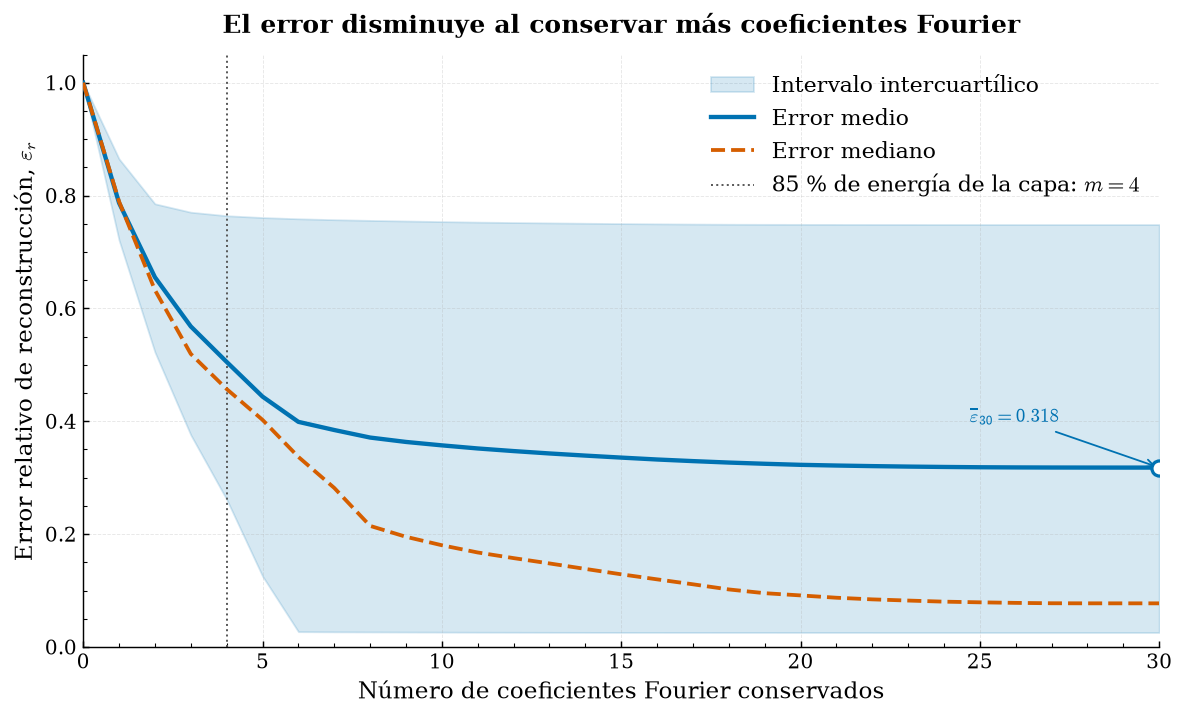

In [70]:
# Número de coeficientes conservados
numero_coeficientes = np.arange(
    N_COEFICIENTES + 1
)

# Cuartiles para mostrar la variabilidad entre señales
percentil_25_error = np.percentile(
    errores_compresion,
    25,
    axis=0
)

percentil_75_error = np.percentile(
    errores_compresion,
    75,
    axis=0
)

fig, ax = plt.subplots(
    figsize=(9.0, 5.4),
    layout="constrained"
)

# Banda intercuartílica
ax.fill_between(
    numero_coeficientes,
    percentil_25_error,
    percentil_75_error,
    color=COLOR_FOURIER,
    alpha=0.16,
    label="Intervalo intercuartílico",
    zorder=1
)

# Error medio
ax.plot(
    numero_coeficientes,
    error_medio_compresion,
    color=COLOR_FOURIER,
    linewidth=2.4,
    linestyle="-",
    label="Error medio",
    zorder=3
)

# Error mediano
ax.plot(
    numero_coeficientes,
    error_mediano_compresion,
    color=COLOR_ALEATORIA,
    linewidth=2.1,
    linestyle="--",
    label="Error mediano",
    zorder=3
)

# Número medio de coeficientes para el umbral energético
if m_85_promedio_capa is not None:
    ax.axvline(
        m_85_promedio_capa,
        color=COLOR_REFERENCIA,
        linewidth=1.1,
        linestyle=":",
        label=(
            rf"85 % de energía de la capa: "
            rf"$m={m_85_promedio_capa}$"
        ),
        zorder=2
    )

# Marcar el resultado con todos los coeficientes
ax.scatter(
    N_COEFICIENTES,
    error_medio_compresion[-1],
    facecolor="white",
    edgecolor=COLOR_FOURIER,
    linewidth=1.8,
    s=70,
    zorder=4
)

ax.annotate(
    rf"$\overline{{\varepsilon}}_{{30}}"
    rf"={error_medio_compresion[-1]:.3f}$",
    xy=(
        N_COEFICIENTES,
        error_medio_compresion[-1]
    ),
    xytext=(-105, 25),
    textcoords="offset points",
    color=COLOR_FOURIER,
    fontsize=10.5,
    arrowprops={
        "arrowstyle": "->",
        "color": COLOR_FOURIER,
        "linewidth": 1.0
    }
)

ax.set_xlim(0, N_COEFICIENTES)
ax.set_ylim(0, 1.05)

ax.set_xticks(
    np.arange(
        0,
        N_COEFICIENTES + 1,
        5
    )
)

ax.set_xlabel(
    "Número de coeficientes Fourier conservados"
)

ax.set_ylabel(
    r"Error relativo de reconstrucción, $\varepsilon_r$"
)

ax.set_title(
    "El error disminuye al conservar más coeficientes Fourier",
    pad=12
)

ax.grid(
    True,
    which="major",
    color="#B0B0B0",
    linestyle="--",
    linewidth=0.5,
    alpha=0.30,
    zorder=0
)

ax.legend(
    loc="upper right",
    frameon=False
)

plt.show()

**Figura 7. Error relativo de reconstrucción frente al número de coeficientes Fourier conservados.**

Para cada señal se ordenaron los 30 coeficientes reales según su contribución
energética y se conservaron primero los de mayor magnitud. La curva azul
representa el error relativo medio de las 30 señales, mientras que la curva
naranja representa la mediana. La banda sombreada corresponde al intervalo
entre los percentiles 25 y 75.

El error con cero coeficientes es igual a uno porque la reconstrucción es la
señal nula. Al aumentar el número de coeficientes, el error disminuye de manera
monótona.

Incluso al conservar los 30 coeficientes disponibles, el error medio no se hace
cero, pues la capa solo contiene frecuencias entre $k=1$ y $k=15$. Las
componentes espectrales externas a ese intervalo no pueden recuperarse mediante
esta base.

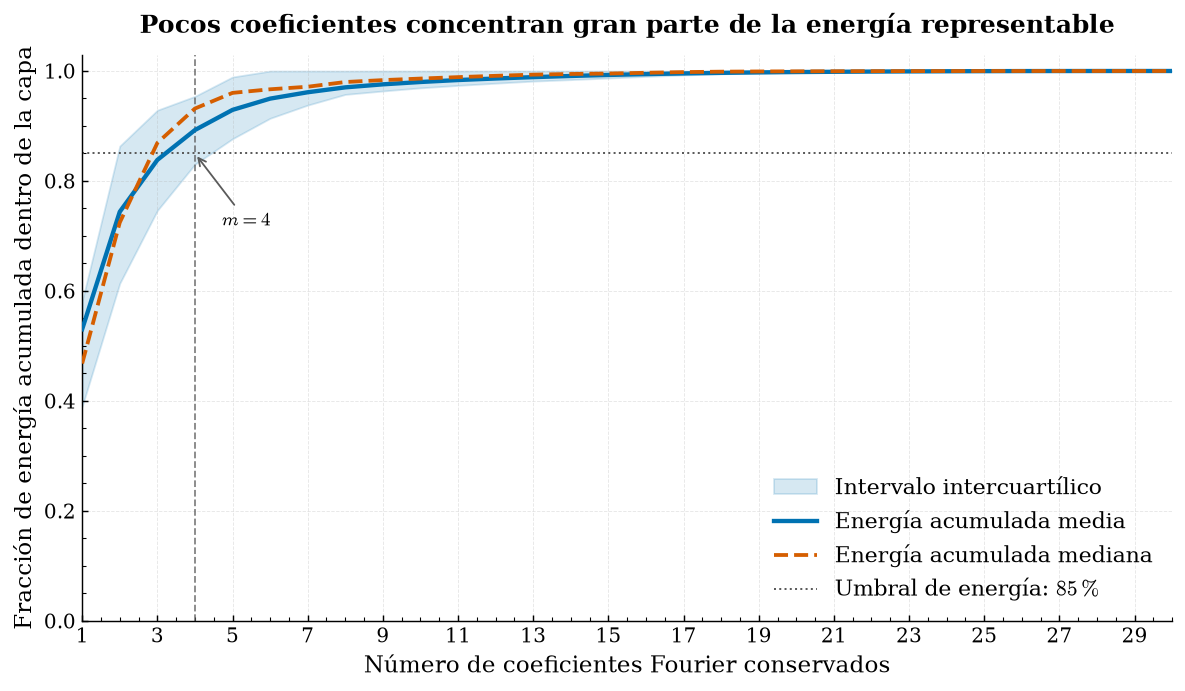

In [71]:
# Mediana y cuartiles de la energía acumulada dentro de la capa
mediana_energia_capa = np.median(
    energia_acumulada_capa,
    axis=0
)

p25_energia_capa = np.percentile(
    energia_acumulada_capa,
    25,
    axis=0
)

p75_energia_capa = np.percentile(
    energia_acumulada_capa,
    75,
    axis=0
)

# La energía acumulada empieza en m = 1
m_coeficientes = np.arange(
    1,
    N_COEFICIENTES + 1
)

fig, ax = plt.subplots(
    figsize=(9.0, 5.2),
    layout="constrained"
)

ax.fill_between(
    m_coeficientes,
    p25_energia_capa,
    p75_energia_capa,
    color=COLOR_FOURIER,
    alpha=0.16,
    label="Intervalo intercuartílico",
    zorder=1
)

ax.plot(
    m_coeficientes,
    energia_media_acumulada_capa,
    color=COLOR_FOURIER,
    linewidth=2.4,
    label="Energía acumulada media",
    zorder=3
)

ax.plot(
    m_coeficientes,
    mediana_energia_capa,
    color=COLOR_ALEATORIA,
    linewidth=2.1,
    linestyle="--",
    label="Energía acumulada mediana",
    zorder=3
)

ax.axhline(
    UMBRAL_ENERGIA,
    color=COLOR_REFERENCIA,
    linewidth=1.1,
    linestyle=":",
    label=r"Umbral de energía: $85\,\%$",
    zorder=2
)

if m_85_promedio_capa is not None:
    ax.axvline(
        m_85_promedio_capa,
        color=COLOR_REFERENCIA,
        linewidth=1.0,
        linestyle="--",
        alpha=0.75,
        zorder=2
    )

    ax.annotate(
        rf"$m={m_85_promedio_capa}$",
        xy=(
            m_85_promedio_capa,
            UMBRAL_ENERGIA
        ),
        xytext=(15, -40),
        textcoords="offset points",
        fontsize=10.5,
        arrowprops={
            "arrowstyle": "->",
            "color": COLOR_REFERENCIA,
            "linewidth": 1.0
        }
    )

ax.set_xlim(1, N_COEFICIENTES)
ax.set_ylim(0, 1.03)

ax.set_xticks(
    np.arange(
        1,
        N_COEFICIENTES + 1,
        2
    )
)

ax.set_xlabel(
    "Número de coeficientes Fourier conservados"
)

ax.set_ylabel(
    "Fracción de energía acumulada dentro de la capa"
)

ax.set_title(
    "Pocos coeficientes concentran gran parte de la energía representable",
    pad=12
)

ax.grid(
    True,
    which="major",
    color="#B0B0B0",
    linestyle="--",
    linewidth=0.5,
    alpha=0.30,
    zorder=0
)

ax.legend(
    loc="lower right",
    frameon=False
)

plt.show()

**Figura 8. Energía acumulada al conservar los coeficientes Fourier de mayor contribución.**

Los coeficientes se ordenaron individualmente de mayor a menor energía para cada
señal. La energía acumulada se normalizó respecto a la energía representada por
los 30 coeficientes disponibles en la capa Fourier.

La línea horizontal indica el umbral personalizado del $85\,\%$. La línea
vertical señala el menor número de coeficientes para el cual la energía
acumulada media alcanza dicho umbral.

Este procedimiento corresponde a una compresión adaptativa o de mejores
$m$ términos: los coeficientes conservados pueden ser diferentes para cada
señal, dependiendo de dónde se concentre su energía espectral.El valor $m=4$ corresponde al $85\,\%$ de la energía representada dentro de la
capa Fourier disponible, no necesariamente al $85\,\%$ de la energía total de
la señal.

# Conclusiones

La matriz Fourier construida con $K=15$ frecuencias produjo una capa de
dimensiones:

$$
W_1\in\mathbb{R}^{30\times256}.
$$

La comparacion con `np.fft` mostro un error maximo de aproximadamente:

$$
9.59\times10^{-14},
$$

y un error relativo global de:

$$
2.70\times10^{-15}.
$$

Por tanto, la implementacion matricial reproduce correctamente los coeficientes
de la transformada discreta de Fourier dentro de la precision numerica.

La energia media del conjunto de datos fue:

$$
E_{\mathrm{media}}=0.715.
$$

Despues de corregir la escala de la perdida y evitar la saturacion inicial de la
capa Fourier, ambas redes bajaron del error relativo medio $0.1$ dentro de las
4000 iteraciones. La inicializacion Fourier lo hizo en la iteracion 976, y la
inicializacion aleatoria en la iteracion 559.

Los errores relativos medios finales fueron:

$$
\overline{\varepsilon}_F=0.0602,
\qquad
\overline{\varepsilon}_A=0.0333.
$$

La perdida final fue:

$$
\mathcal{L}_F=0.893,
\qquad
\mathcal{L}_A=0.196.
$$

En esta ejecucion, la inicializacion aleatoria escalada alcanzo menor error
final que Fourier. Esto no contradice la utilidad de la base Fourier: la
correccion de escala evita la saturacion de $\tanh$ y permite que ambas redes
converjan, pero el punto de partida Fourier no garantiza por si solo la mejor
trayectoria de optimizacion.

Por regimen, los errores medios finales fueron:

$$
\overline{\varepsilon}_{F,0}=0.0485,
\qquad
\overline{\varepsilon}_{A,0}=0.0351,
$$

$$
\overline{\varepsilon}_{F,1}=0.0578,
\qquad
\overline{\varepsilon}_{A,1}=0.0305,
$$

$$
\overline{\varepsilon}_{F,2}=0.0742,
\qquad
\overline{\varepsilon}_{A,2}=0.0342.
$$

El regimen $2$ fue el mas dificil para la red Fourier, mientras que el regimen
$0$ tuvo el mayor error medio para la red aleatoria. En el regimen foco,
Fourier bajo de $0.1$ en la iteracion 1149 y la inicializacion aleatoria en la
iteracion 639. La dificultad del regimen $2$ para la base Fourier se explica
porque, para $\mu=15$, las frecuencias fisicas cumplen:

$$
\omega(k)=\sqrt{k^2+15^2}\in[15.03,18.60]
\quad (k=1,\ldots,11),
$$

por lo que no coinciden exactamente con las frecuencias enteras de la base y
varias quedan por encima del limite $k=15$. Esto produce fuga espectral y hace
mas exigente la reconstruccion con una base Fourier truncada.

En la compresion espectral, cuatro coeficientes fueron suficientes, en promedio,
para conservar el $85\,\%$ de la energia representada por la capa Fourier.
No obstante, la capa completa capturo en promedio solamente el $75.57\,\%$ de
la energia total del conjunto, con una gran variabilidad entre senales.

Incluso conservando los 30 coeficientes, el error relativo medio fue:

$$
\overline{\varepsilon}_{30}=0.3179.
$$

Este piso de error se debe a que la capa solo contiene las frecuencias
$k=1,\ldots,15$, por lo que no puede reconstruir componentes espectrales fuera
de ese intervalo.


In [292]:
# Ir a la raíz del repositorio
%cd /content/programacionCientifica

# Asegurarse de partir de la rama principal actualizada
!git switch main
!git pull --ff-only origin main

# Crear la rama personal de la Evaluación 2
!git switch -c eval2-Corredor

# Verificar la rama activa
!git branch --show-current

/content/programacionCientifica
Already on 'main'
Your branch is up to date with 'origin/main'.
From https://github.com/manubastidas/programacionCientifica
 * branch            main       -> FETCH_HEAD
Already up to date.
Switched to a new branch 'eval2-Corredor'
eval2-Corredor


In [293]:
# Crear la carpeta de entrega dentro de Evaluacion2
from pathlib import Path

carpeta_entrega = Path(
    "/content/programacionCientifica/Evaluacion2/Corredor"
)

carpeta_entrega.mkdir(
    parents=True,
    exist_ok=True
)

print("Carpeta creada:")
print(carpeta_entrega)

print("\nContenido actual:")
for archivo in carpeta_entrega.iterdir():
    print("-", archivo.name)

Carpeta creada:
/content/programacionCientifica/Evaluacion2/Corredor

Contenido actual:


In [294]:
# Copiar el enunciado y los datos personalizados a la carpeta de entrega
from pathlib import Path
import shutil

carpeta_origen = Path(
    "/content/programacionCientifica/Evaluacion2"
)

carpeta_entrega = Path(
    "/content/programacionCientifica/Evaluacion2/Corredor"
)

archivos_datos = [
    "enunciado_698.md",
    "datos_698.npz"
]

for nombre in archivos_datos:
    origen = carpeta_origen / nombre
    destino = carpeta_entrega / nombre

    if not origen.exists():
        raise FileNotFoundError(
            f"No se encontró el archivo: {origen}"
        )

    shutil.copy2(origen, destino)
    print(f"Copiado correctamente: {destino}")

print("\nContenido actual de la carpeta Corredor:")

for archivo in sorted(carpeta_entrega.iterdir()):
    print("-", archivo.name)

Copiado correctamente: /content/programacionCientifica/Evaluacion2/Corredor/enunciado_698.md
Copiado correctamente: /content/programacionCientifica/Evaluacion2/Corredor/datos_698.npz

Contenido actual de la carpeta Corredor:
- datos_698.npz
- enunciado_698.md
